In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_results.ipynb started: Thu, 14 May 2026 23:42:41
INFO: SETUP COMPLETE (1781.25 ms)
---------------------------------------


In [2]:
# pixe_single_spectrum_plot('.//2026_02_26//20260226-155629.vspc')

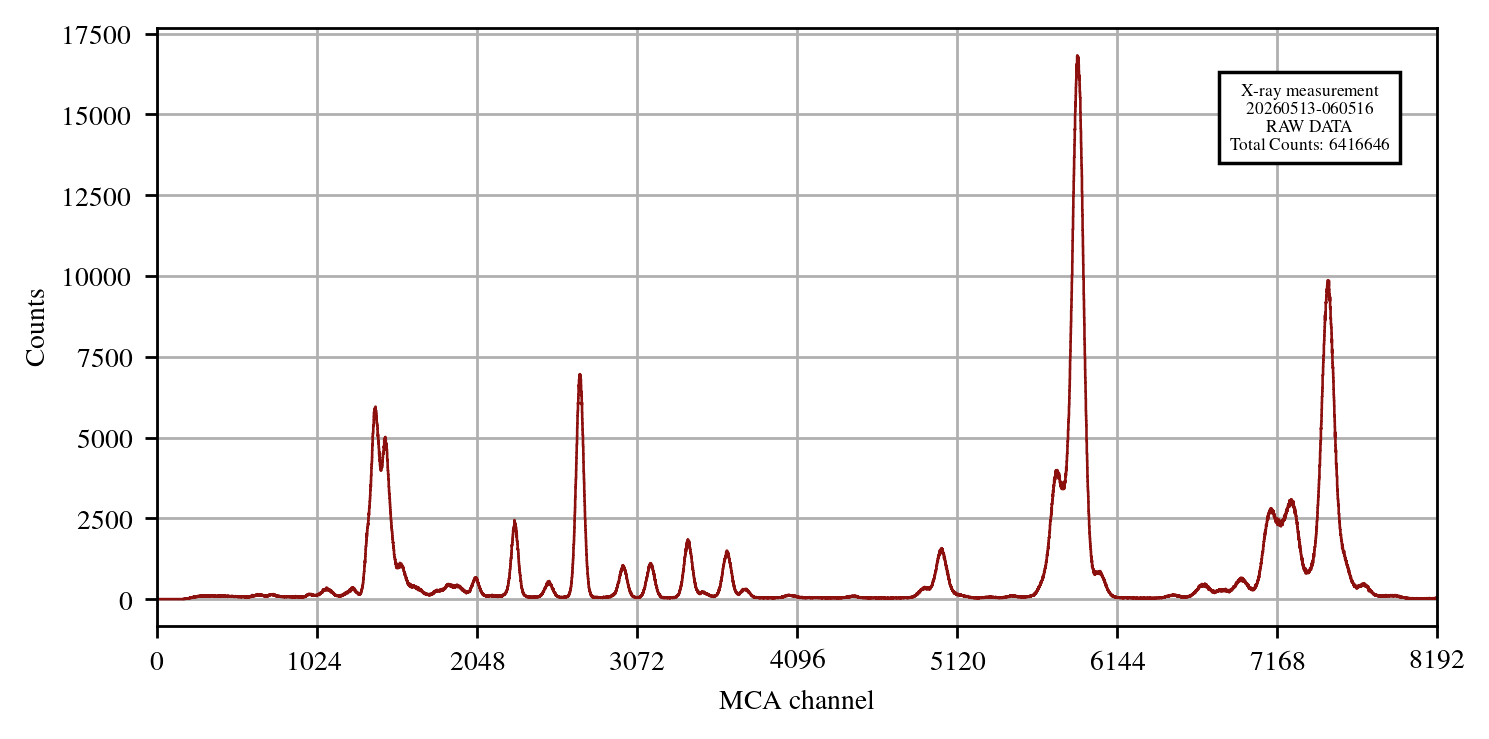

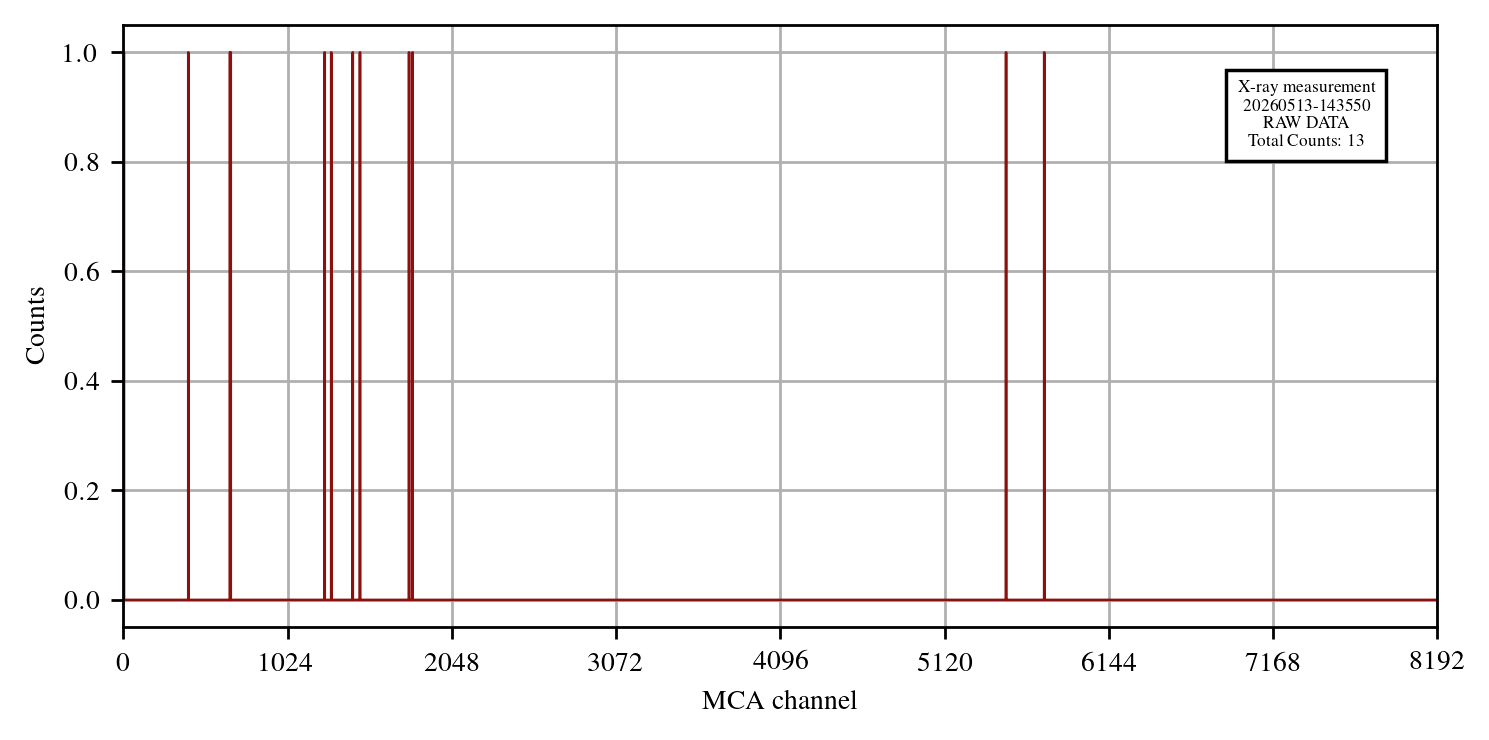

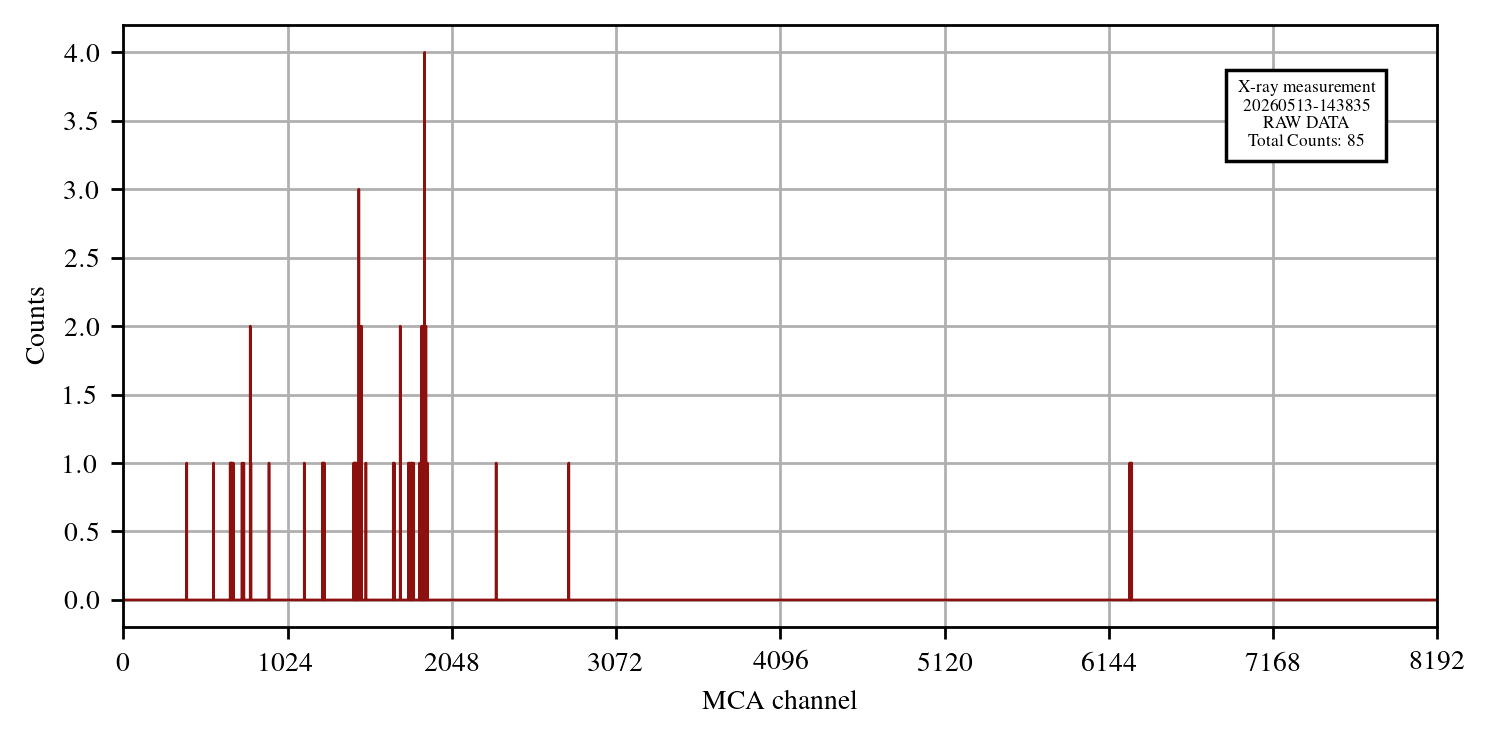

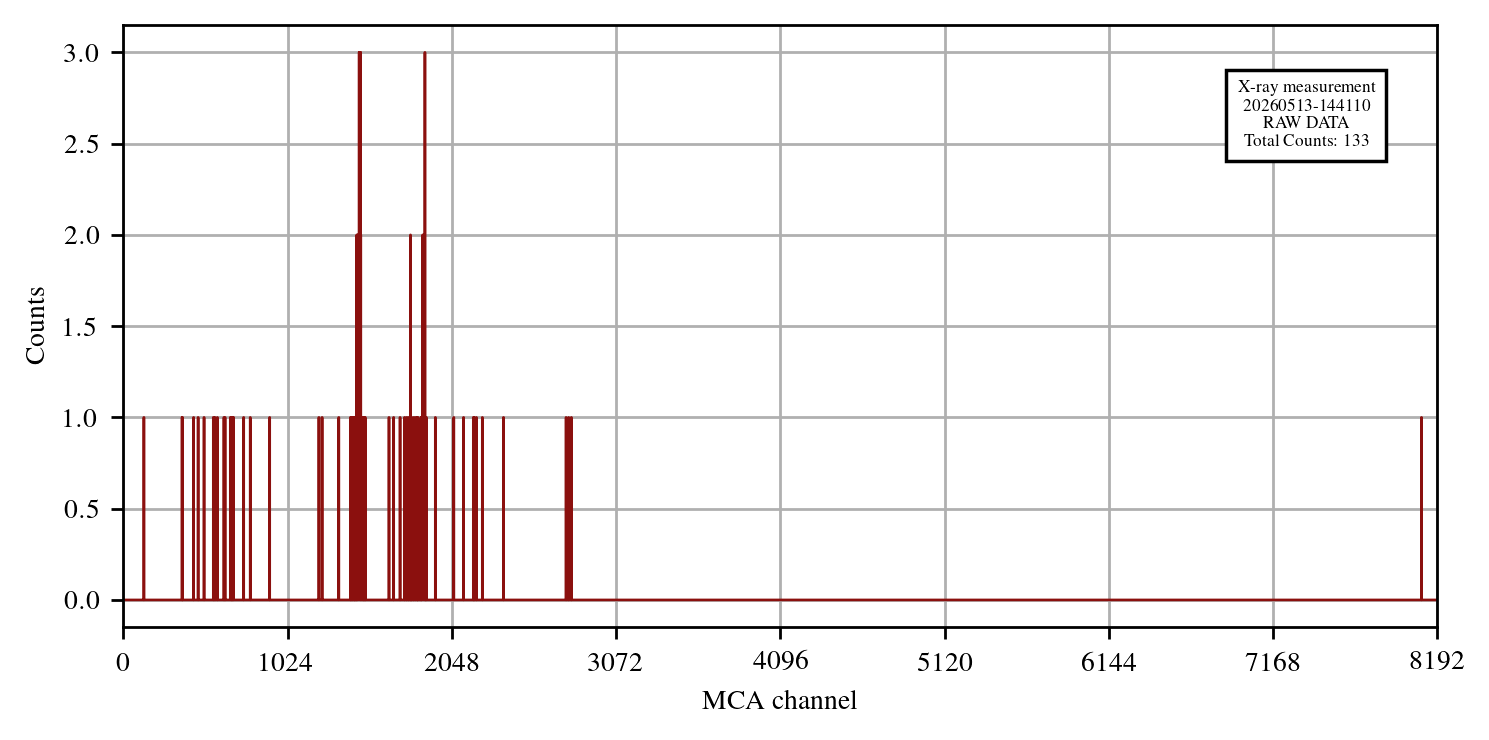

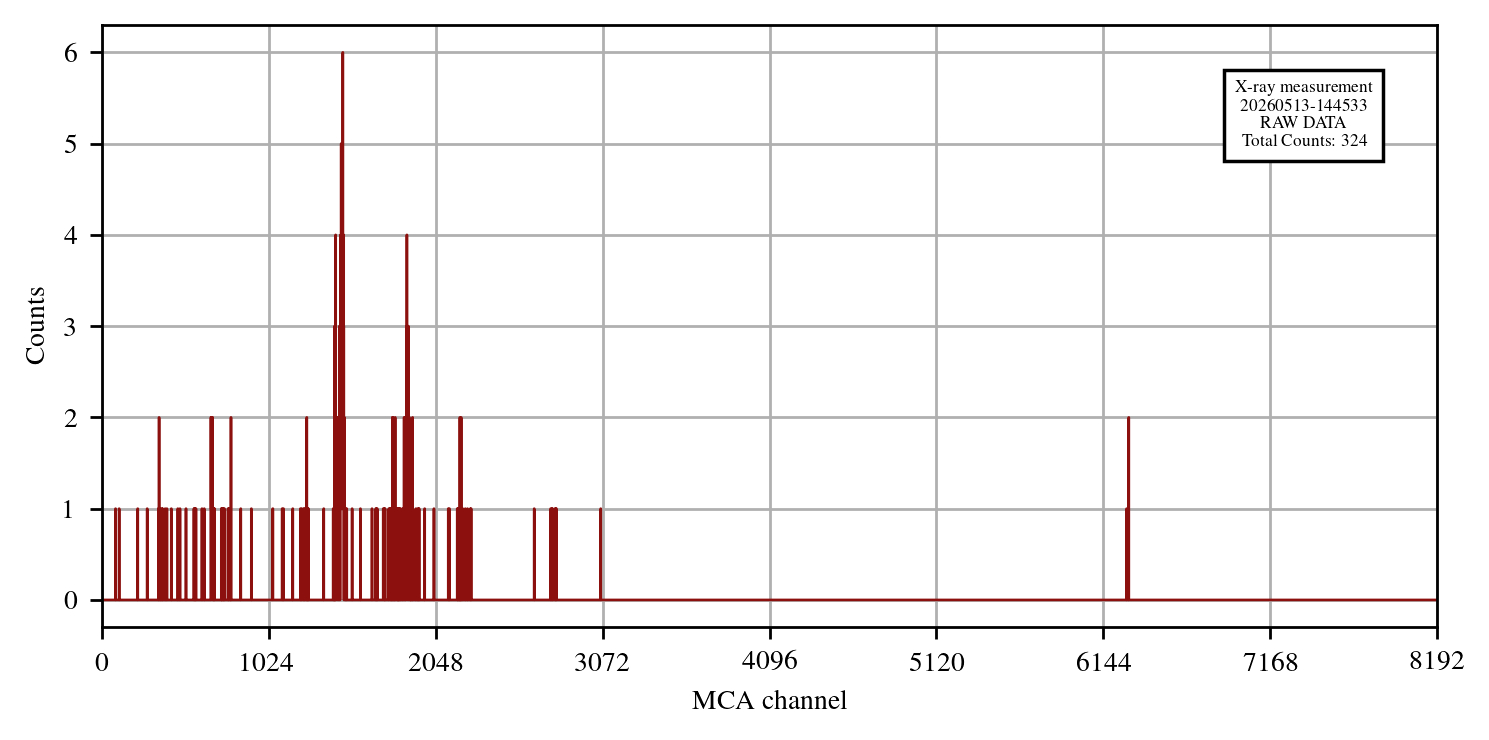

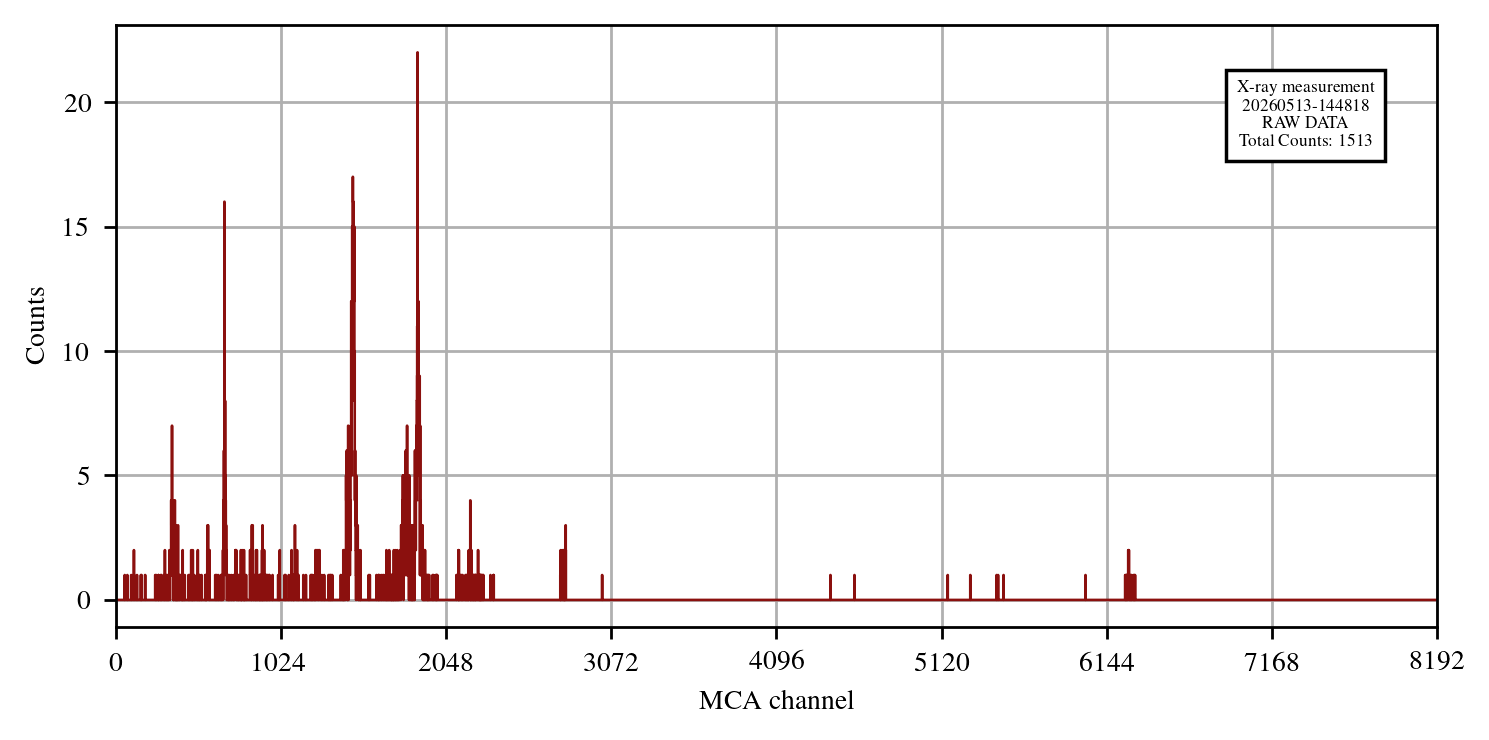

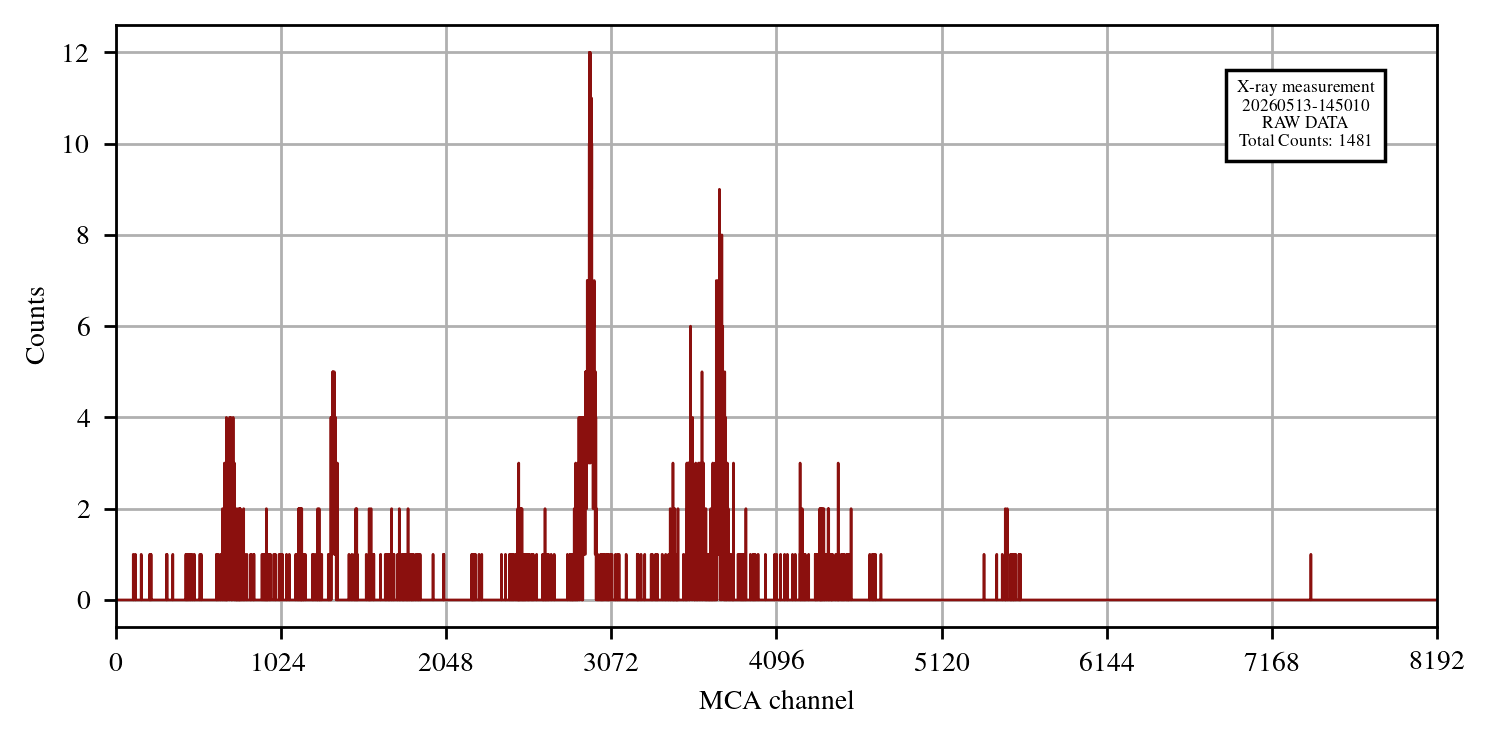

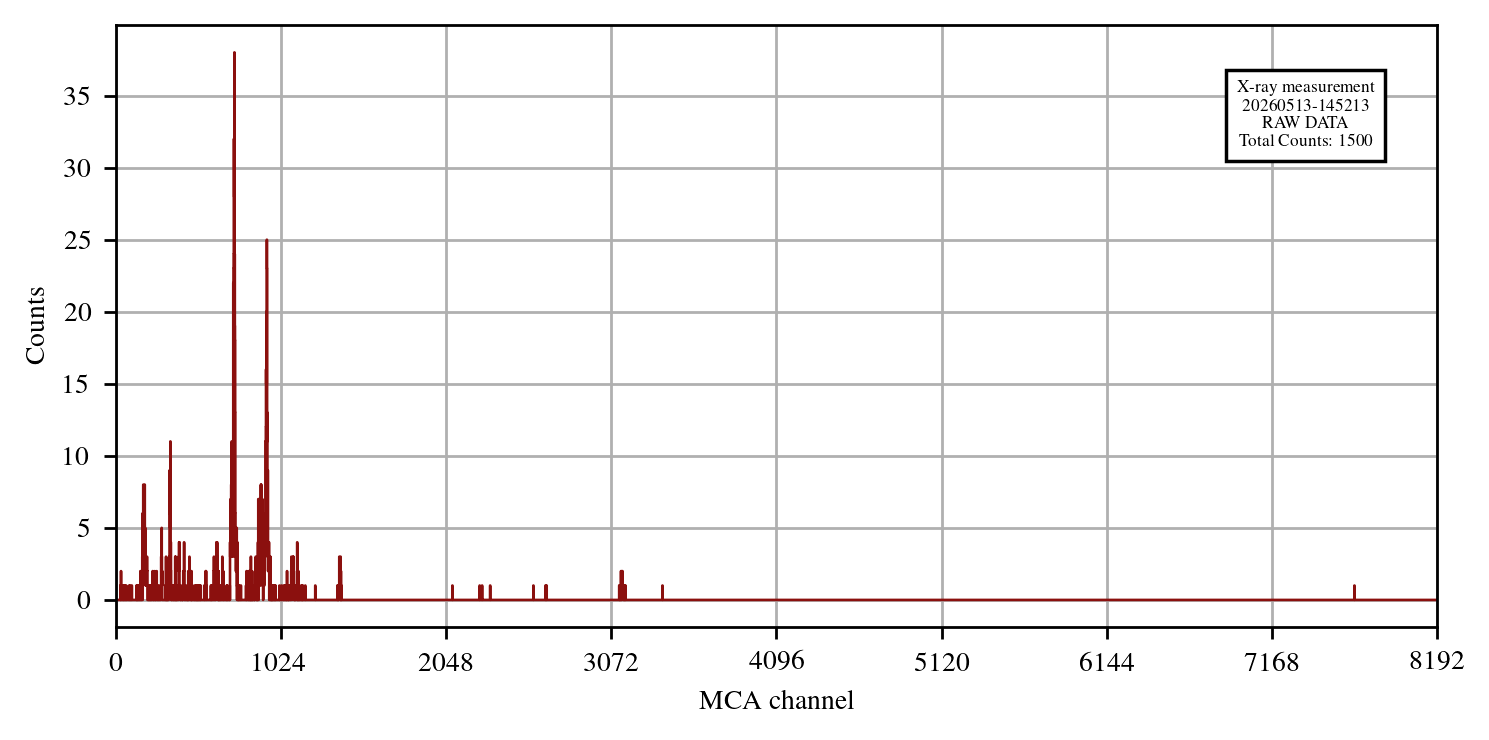

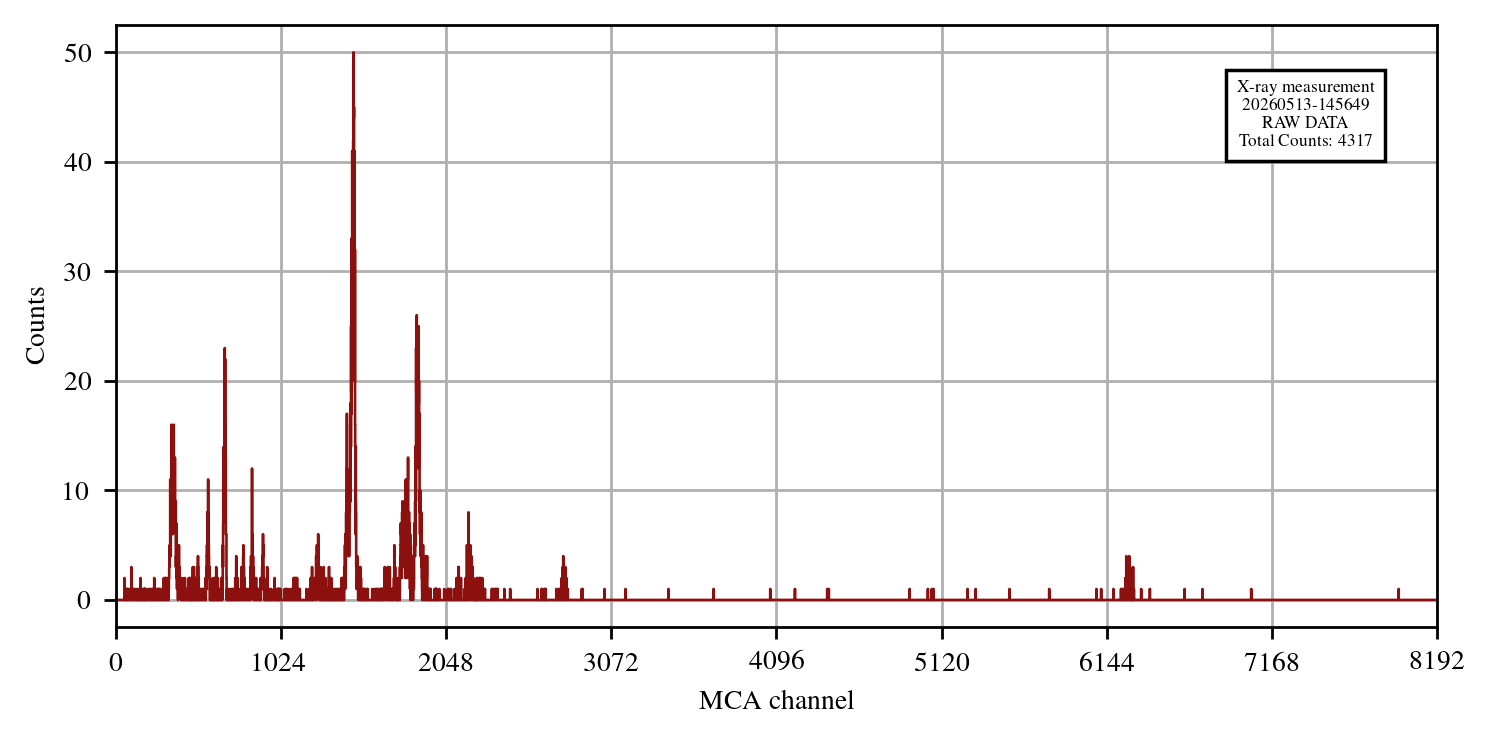

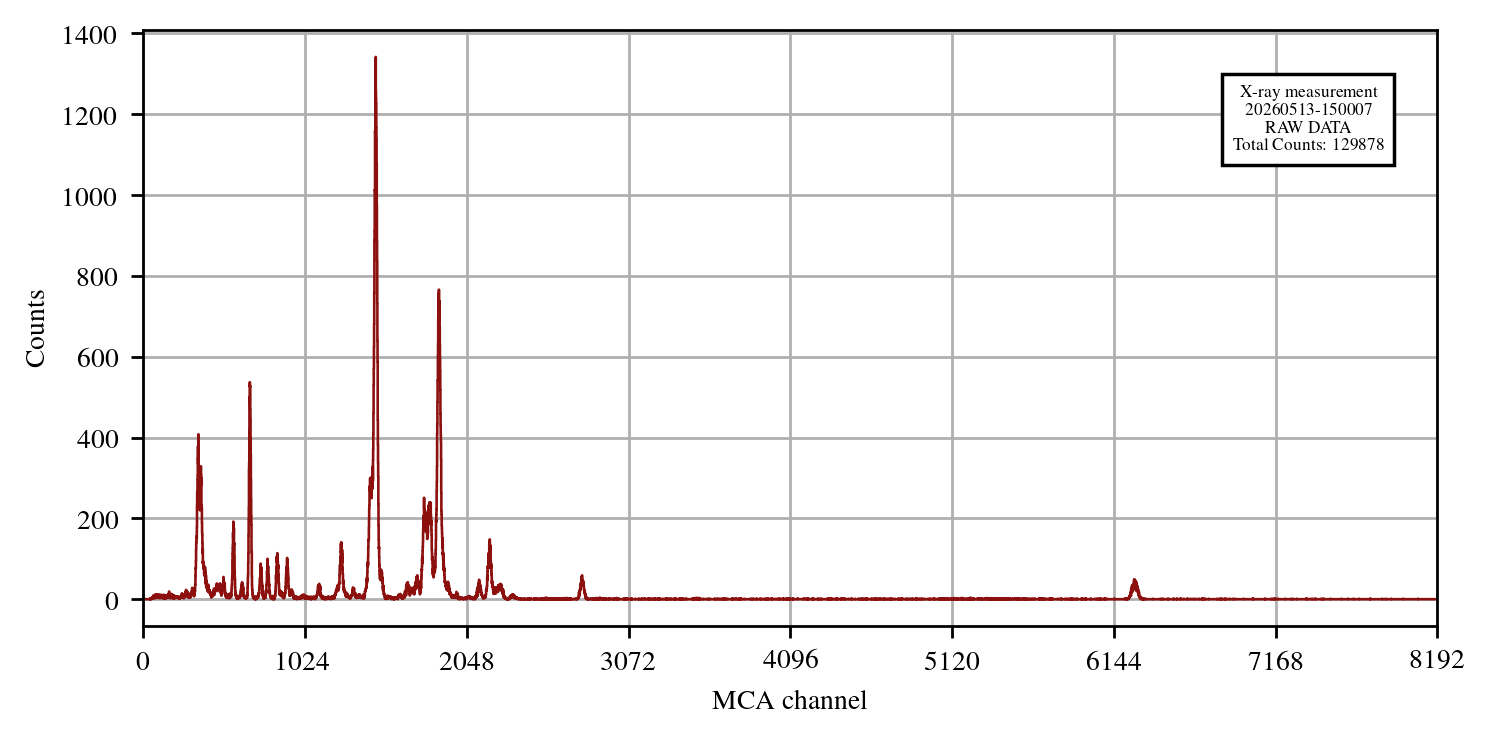

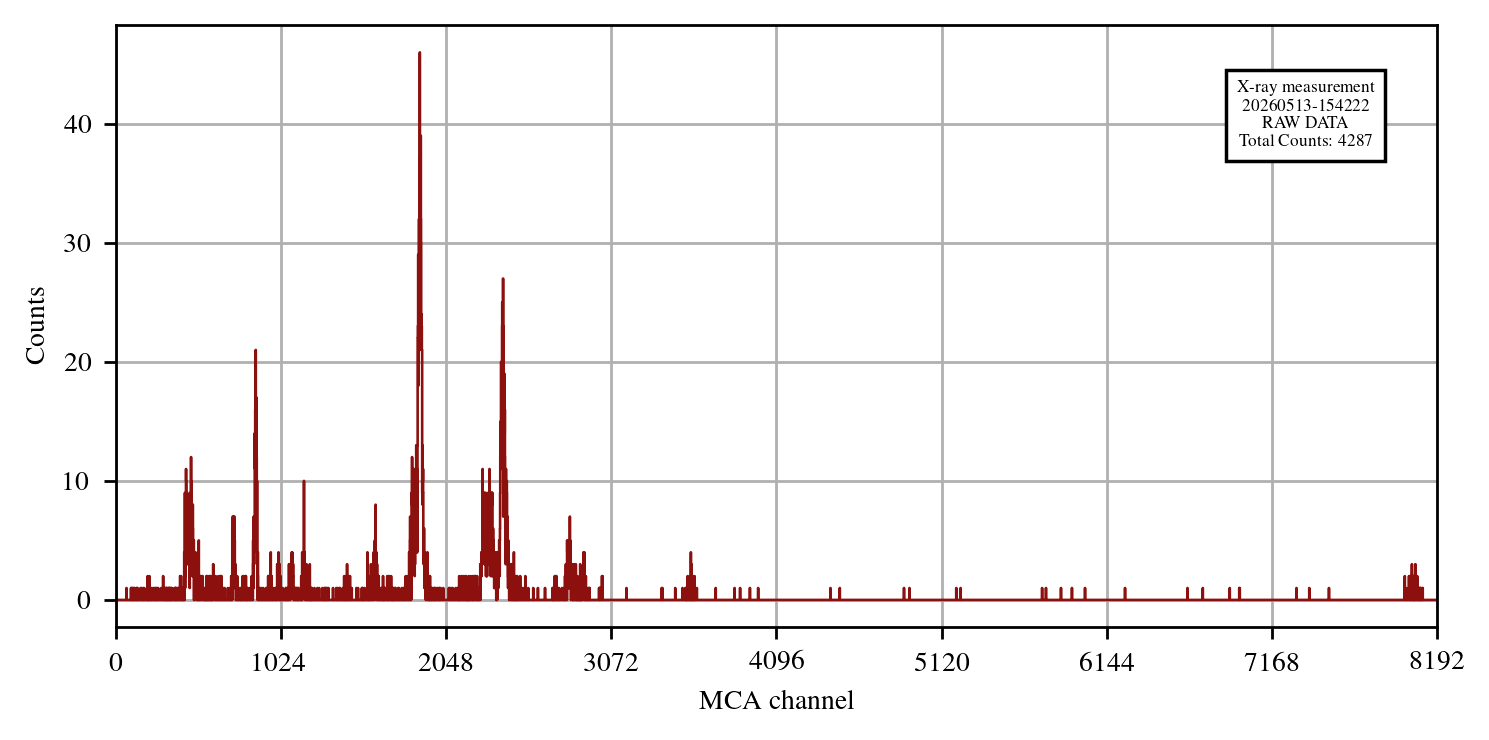

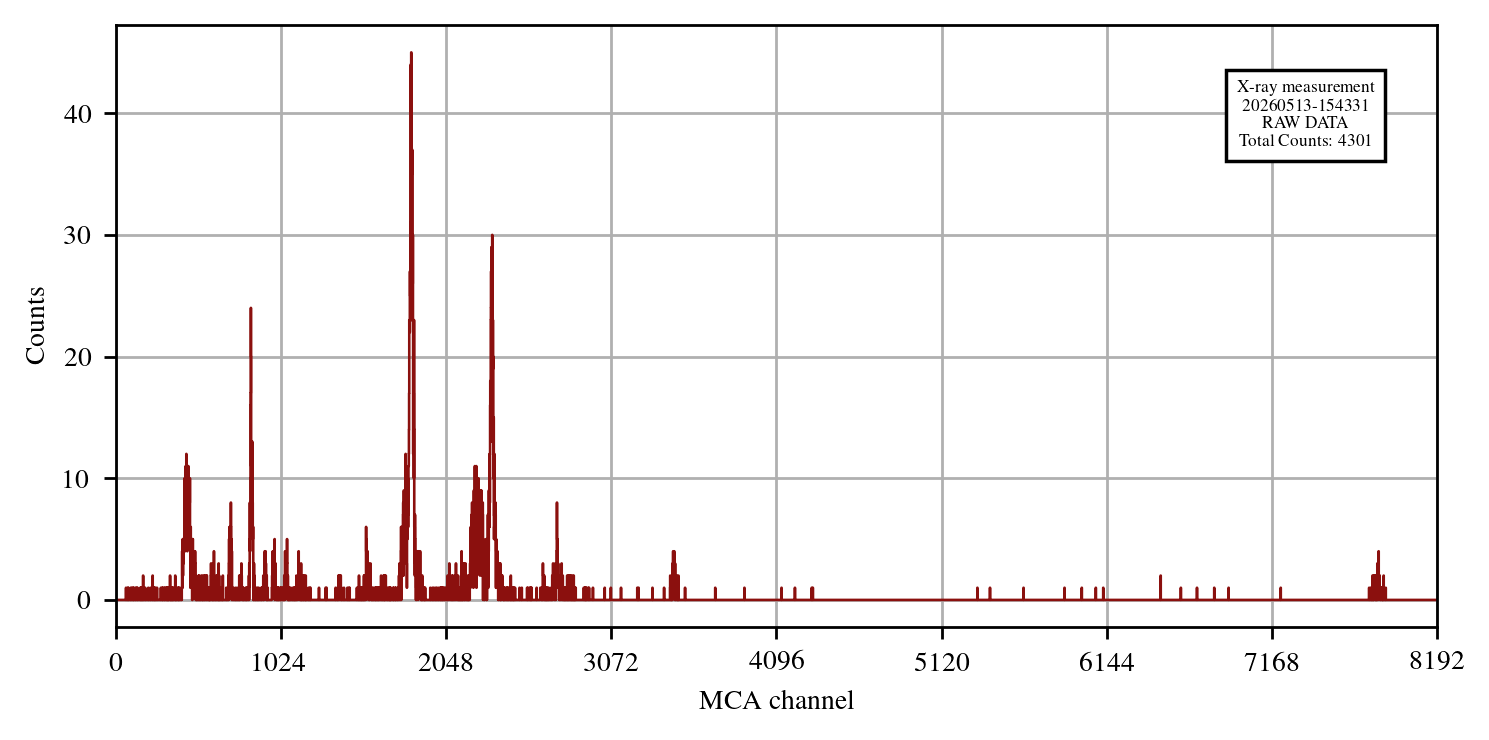

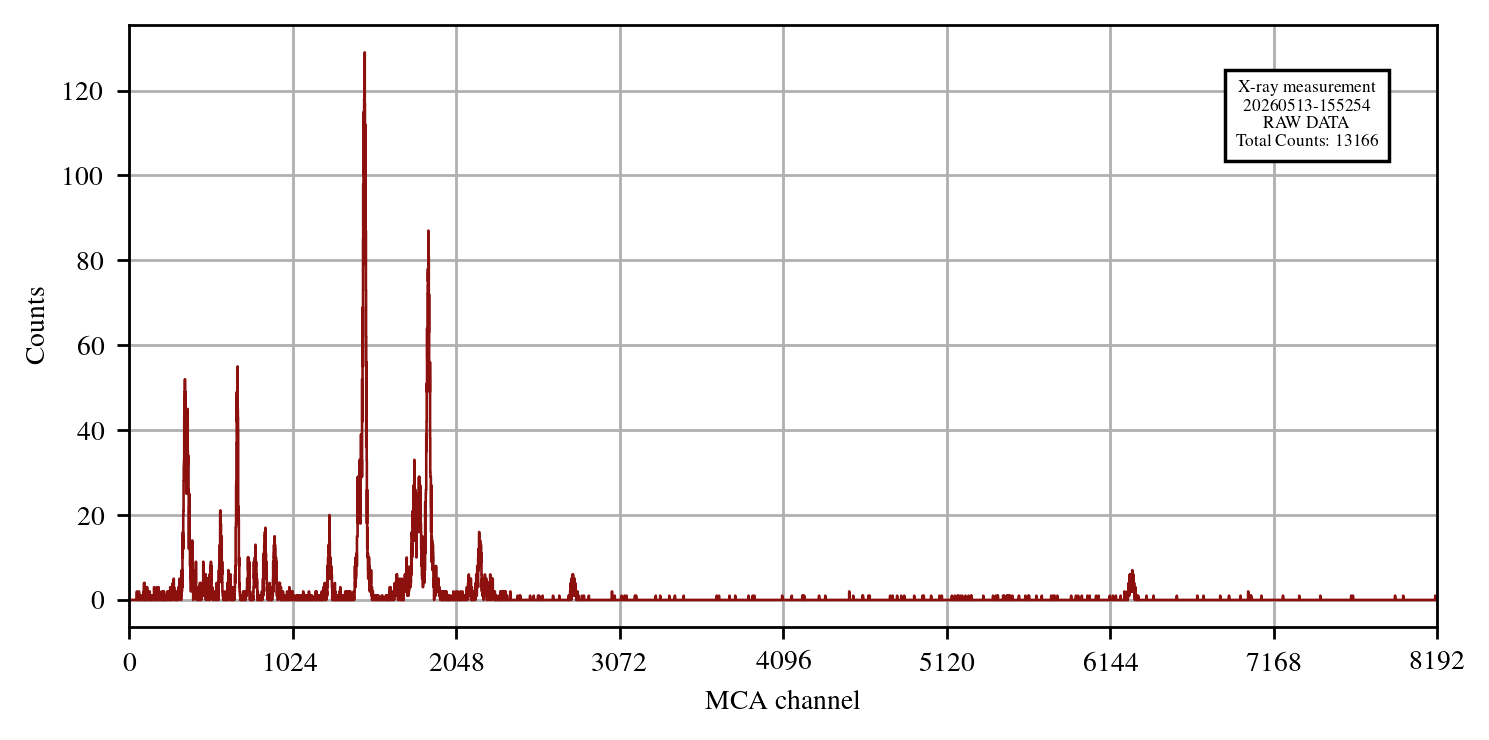

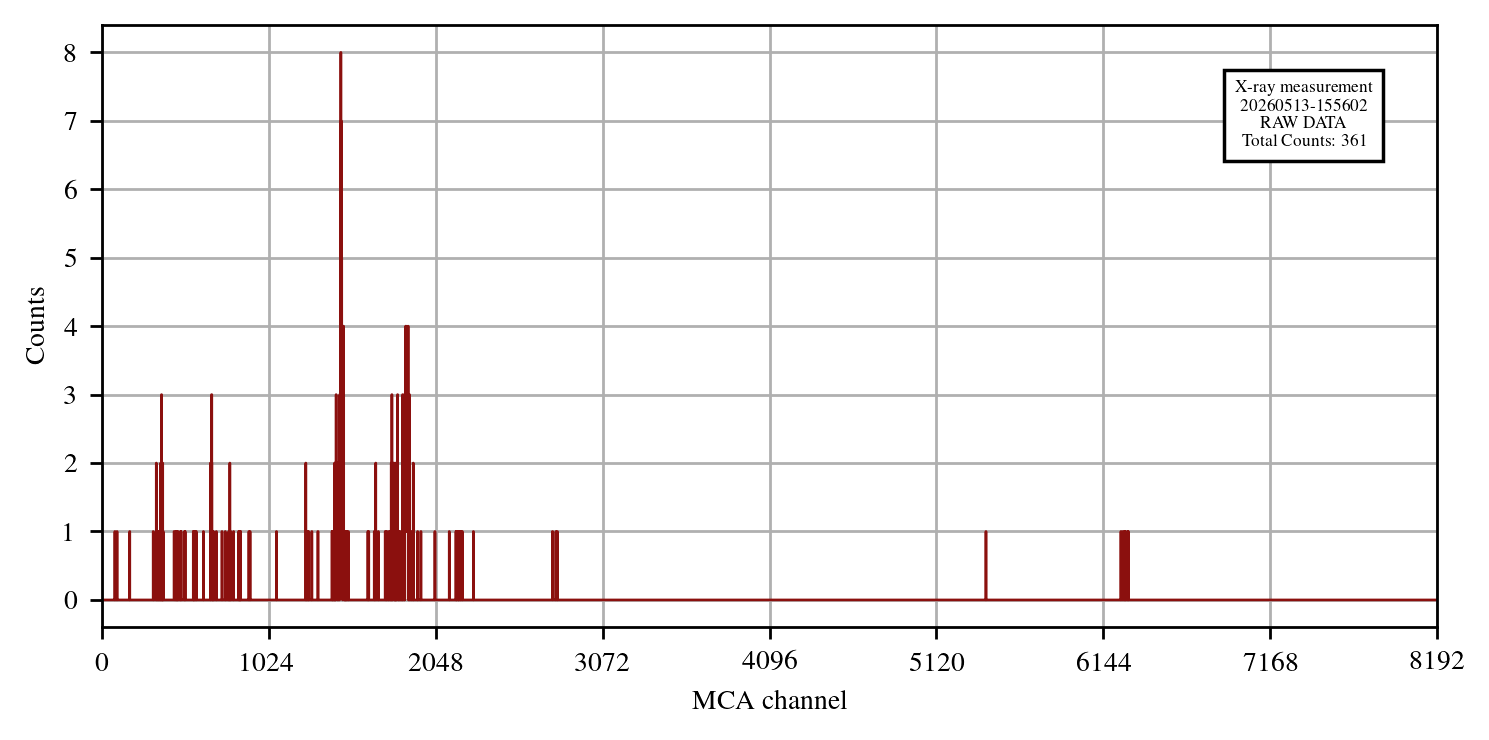

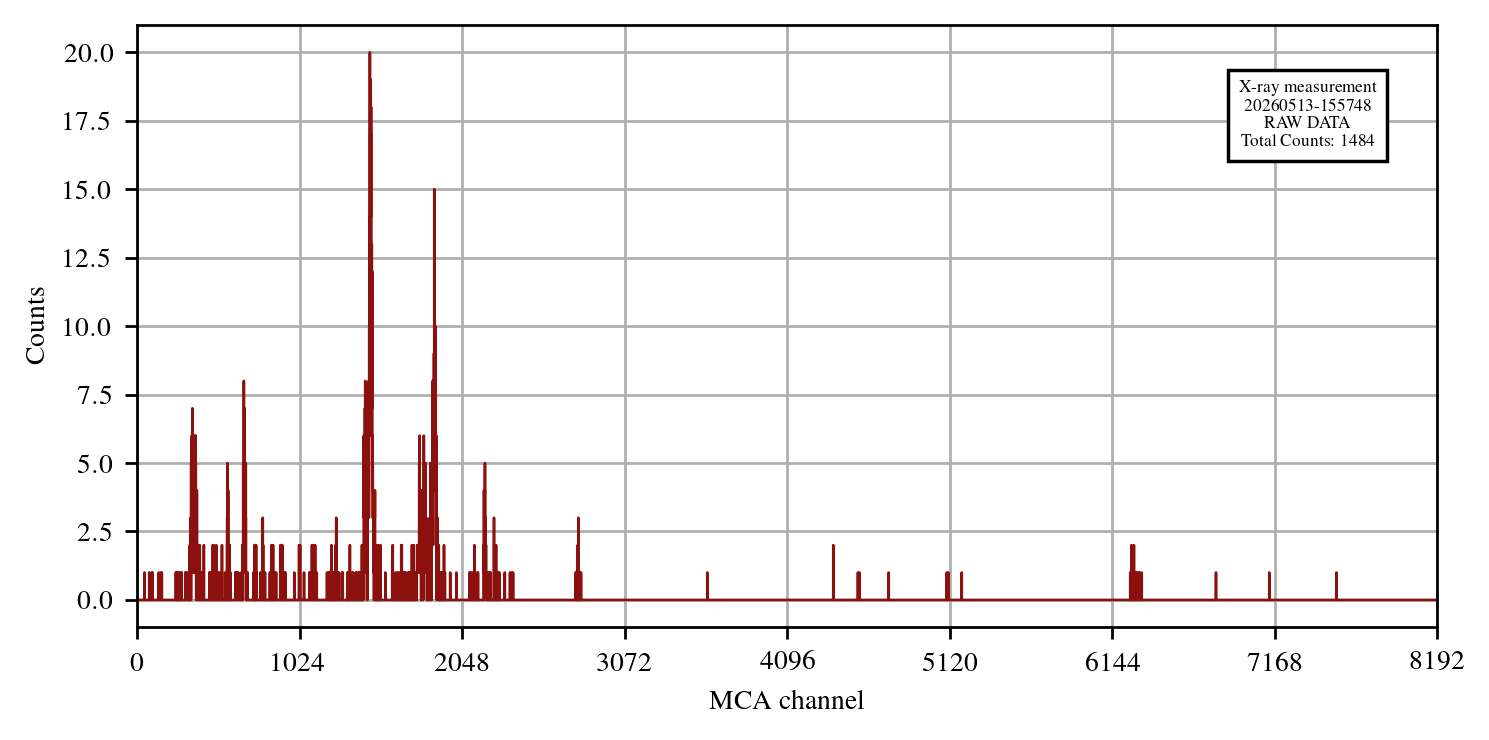

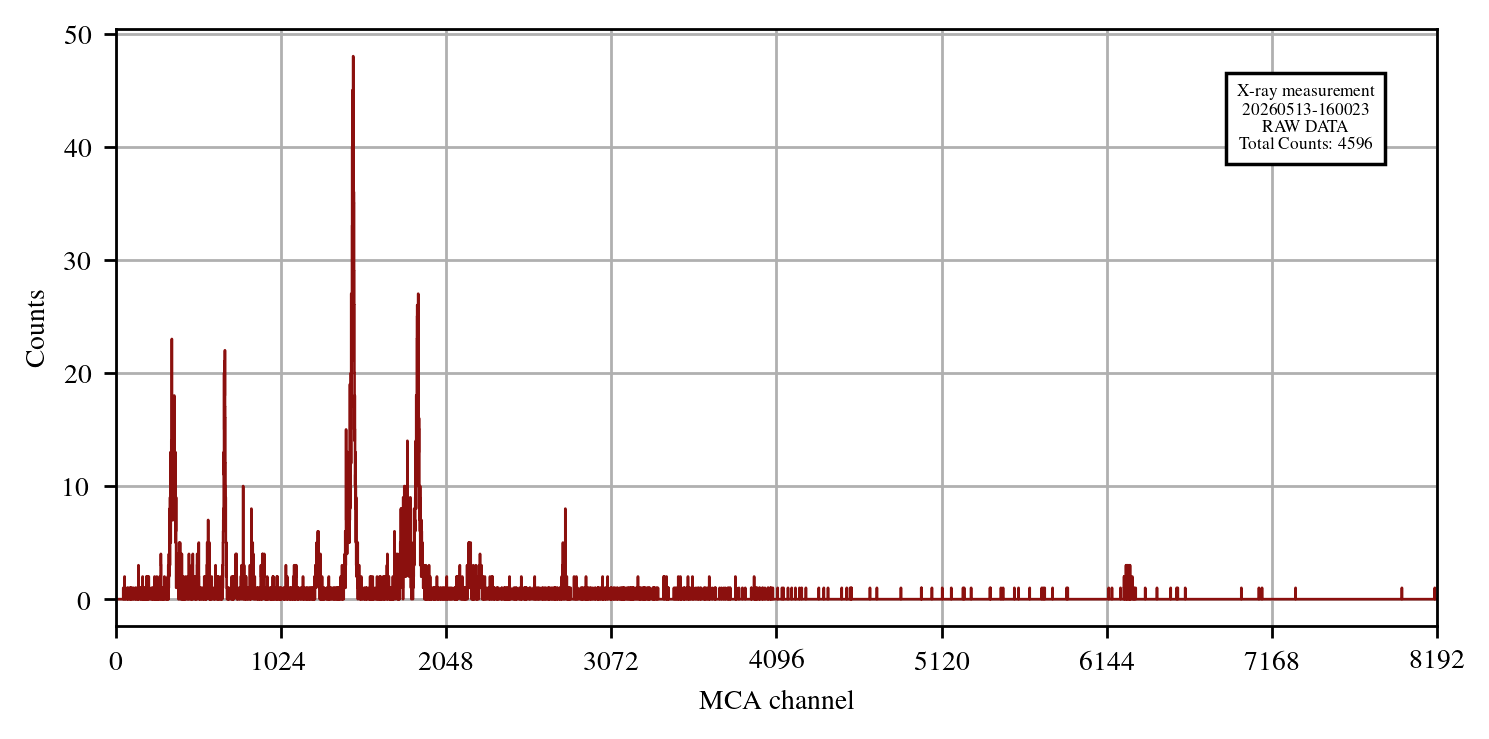

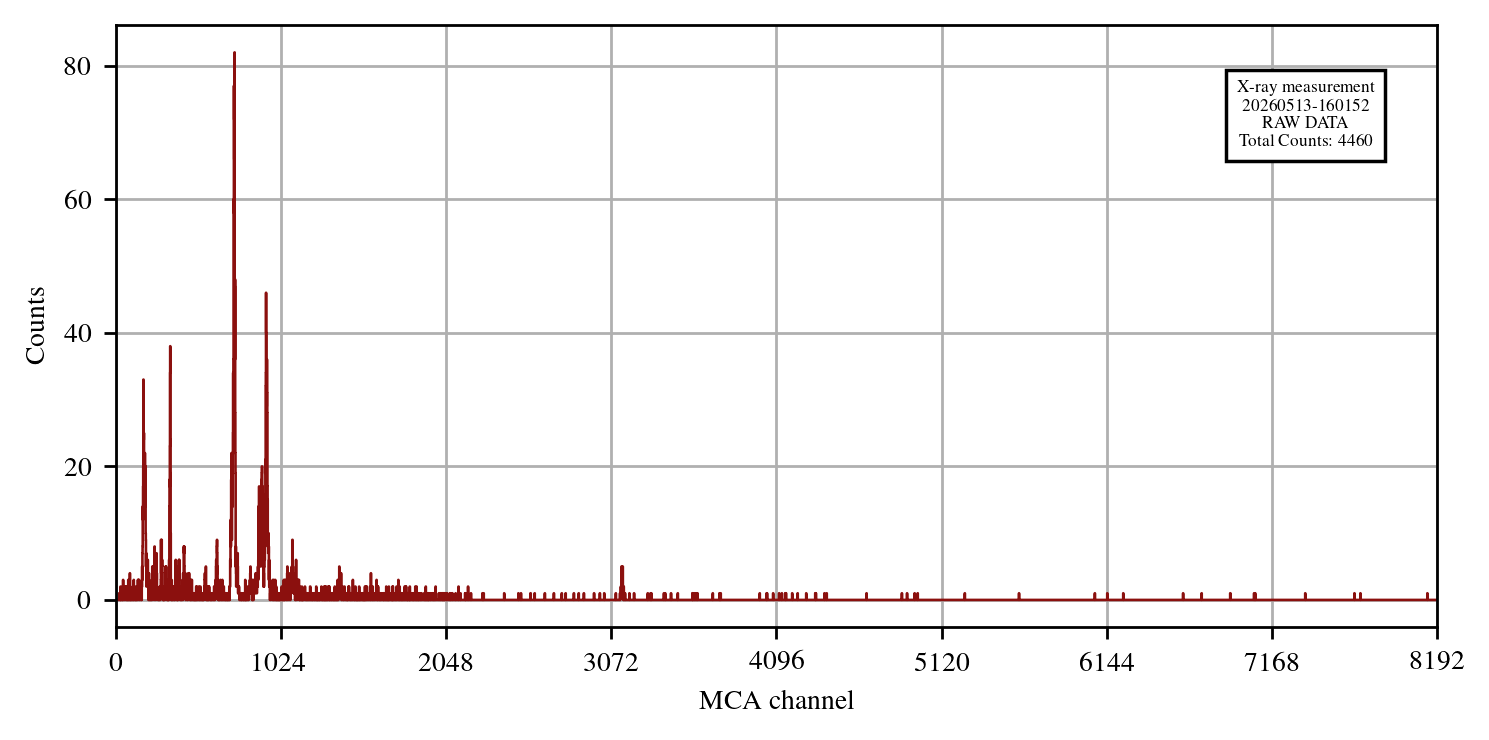

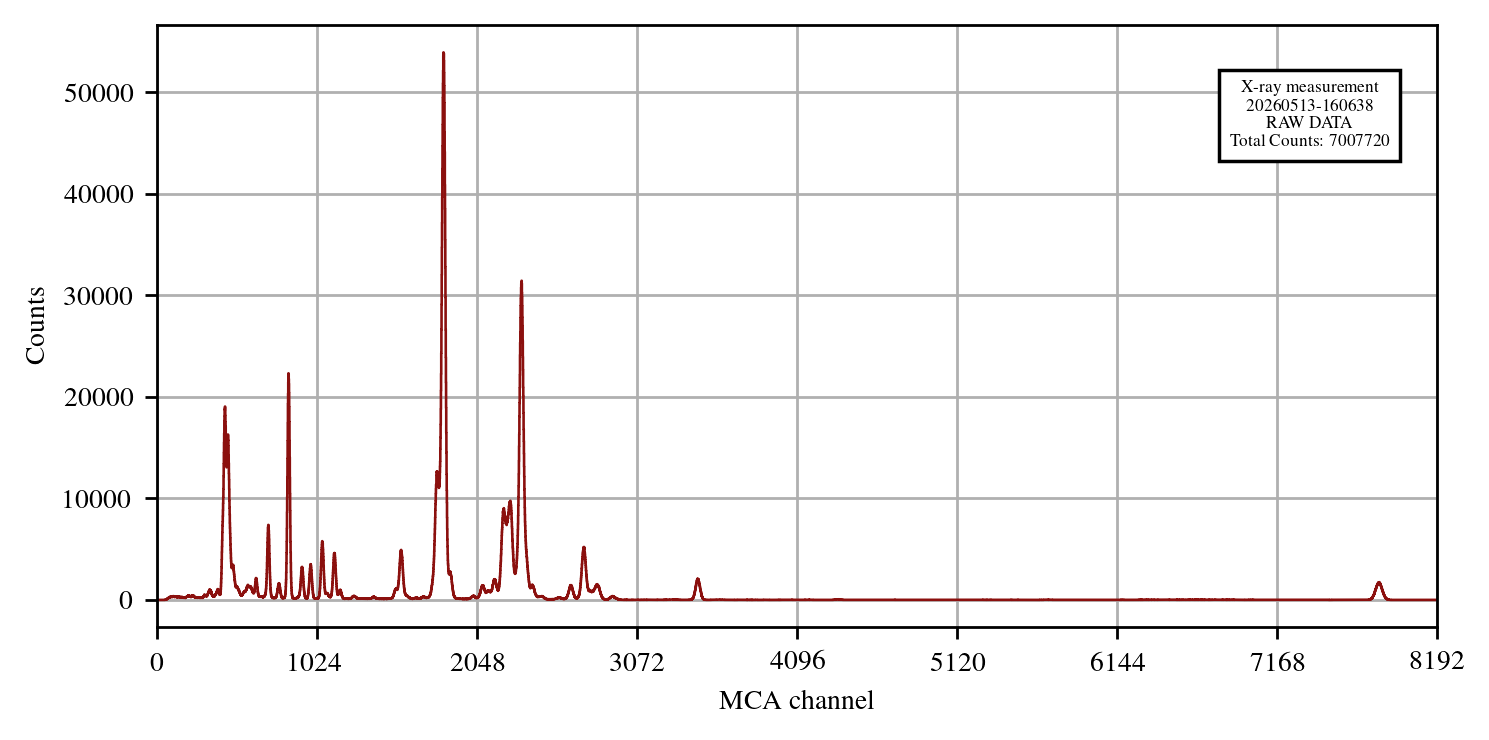

In [2]:
# f_n = all_files_from_measSet('2026_02_26')
# f_n = all_files_from_measSet('2026_02_27')
# f_n = all_files_from_measSet('2026_03_25')
f_n = all_files_from_measSet('collected_data//2026_05_13')

## To-Do:

#### Energy Calibration with Amersham Source Data

#### Upload to Confluence: Docu for Detector

In [2]:
def peak_fitter(file:str, init_values:list, gauss_ident:str):
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    bins = np.arange(0,len(bin_data),1)
    bins_err = np.array([2]*len(bins))
    
    if (gauss_ident == 'single'):
        beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
                           x=bins, y=bin_data, xerr=bins_err, yerr=data_err)
    elif (gauss_ident == 'double'):
        beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
                           x=bins, y=bin_data, xerr=bins_err, yerr=data_err)
    elif (gauss_ident == 'single_lin'):
        beta = evaluator_scipy(func=gauss_linear_func, beta0_list=init_values,
                           x=bins, y=bin_data, xerr=bins_err, yerr=data_err)
    elif (gauss_ident == 'voigt'):
        beta = evaluator_scipy(func=cauchy_voigt_func, beta0_list=init_values,
                           x=bins, y=bin_data, xerr=bins_err, yerr=data_err)
        
    return beta

### To-Do

- Voigt Profile
- Presentation Flag (larger legend, ticks and labels)
- measurement name Flag
- xraydb implementation for manual search
- Double Gauss Split Flag
- Force Gauss from Init Values Flag (see a certain Rb-Measurement)
- For Spectra later, add overlapping lines where fit didn't find them

In [3]:
def all_peaks_one_measurement(file:str, peaks:list, xlim:list, ylim:list, info:list, col_flag:bool, identifier:str, gauss_ident:list):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]}')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
        beta= peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p])
        beta_export = [beta['param'],beta['errors']]
        
        
        if (gauss_ident[p] == 'single'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'single_lin'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_linear_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
              
        
            
        csv_file_name = f'.//peak_idents//{meas_folder}//{meas_name}_peaks_{identifier}.csv'
        
        with open(csv_file_name, mode='a', newline='', encoding='utf-8') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerows(beta_export)
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [4]:
def grab_xrays(elem:str):
    l_fmt = '%7s  %9.1f   %8.5f  %11s'
    print('# X-ray Lines:')
    print('#  Line     Energy  Intensity       Levels')
    for key, val in xraydb.xray_lines(elem).items():
        levels = '%s-%s' % (val.initial_level, val.final_level)
        print(l_fmt % (key, val.energy, val.intensity, levels))
    return 69

## Copper

PARAMS: [ 896.69886282 3398.417712     27.575469  ]
UNCERT: [30.77778342  1.07339063  0.64748584]
PARAMS: [ 153.84709211 3761.30305045   30.14765726]
UNCERT: [13.32974765  2.27526389  1.6582498 ]


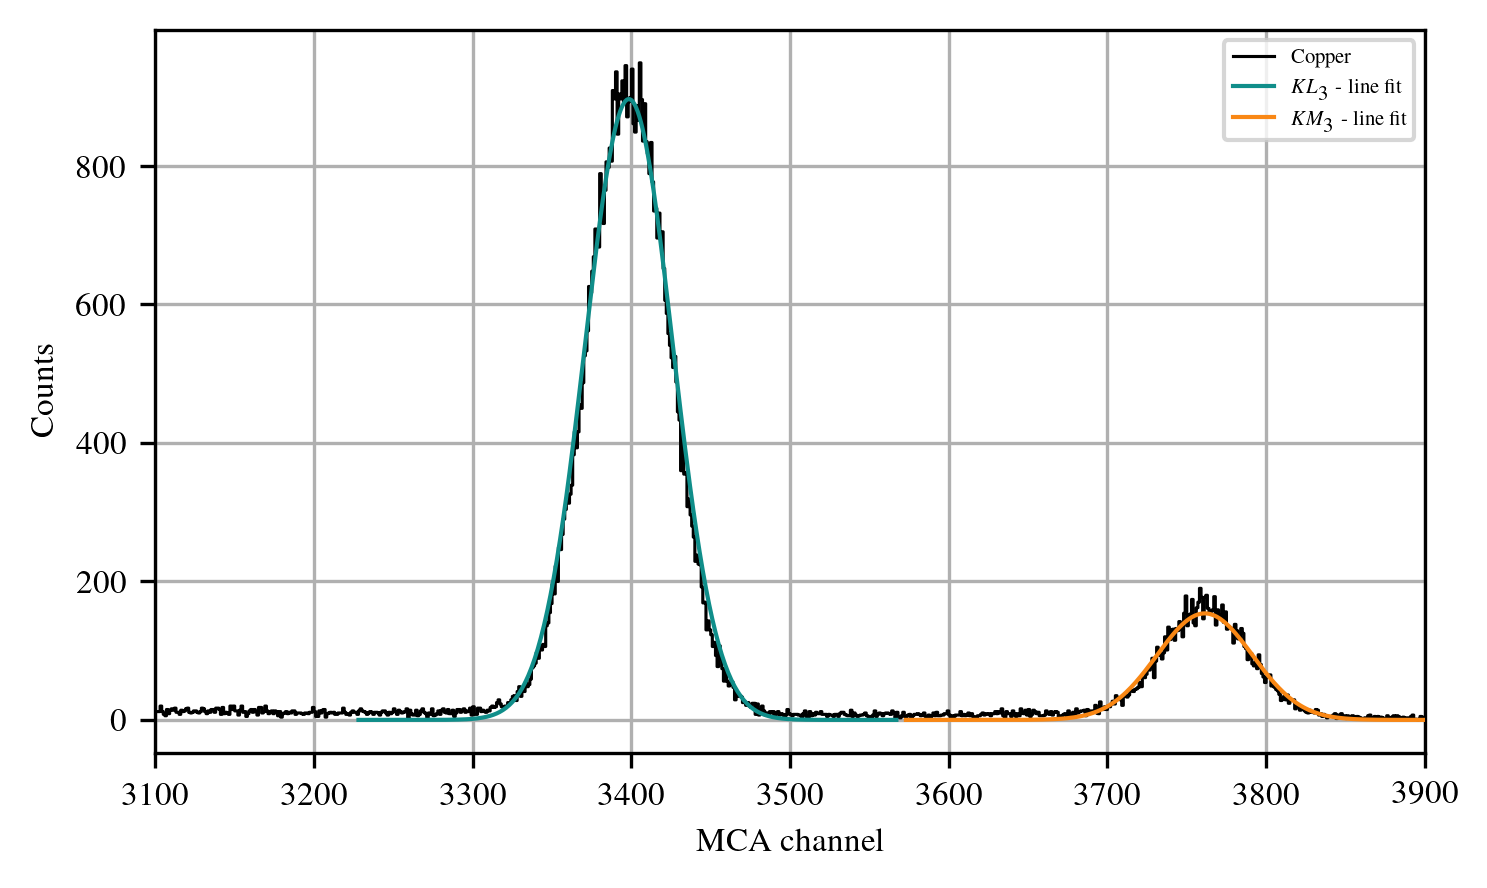

PARAMS: [  13.41490461 2195.06863129 1162.44170852]
UNCERT: [ 0.27535555 22.70630032 18.05532838]
PARAMS: [  13.41507649 2195.07310035 1162.42262467]
UNCERT: [ 0.27535771 22.70605604 18.0550286 ]


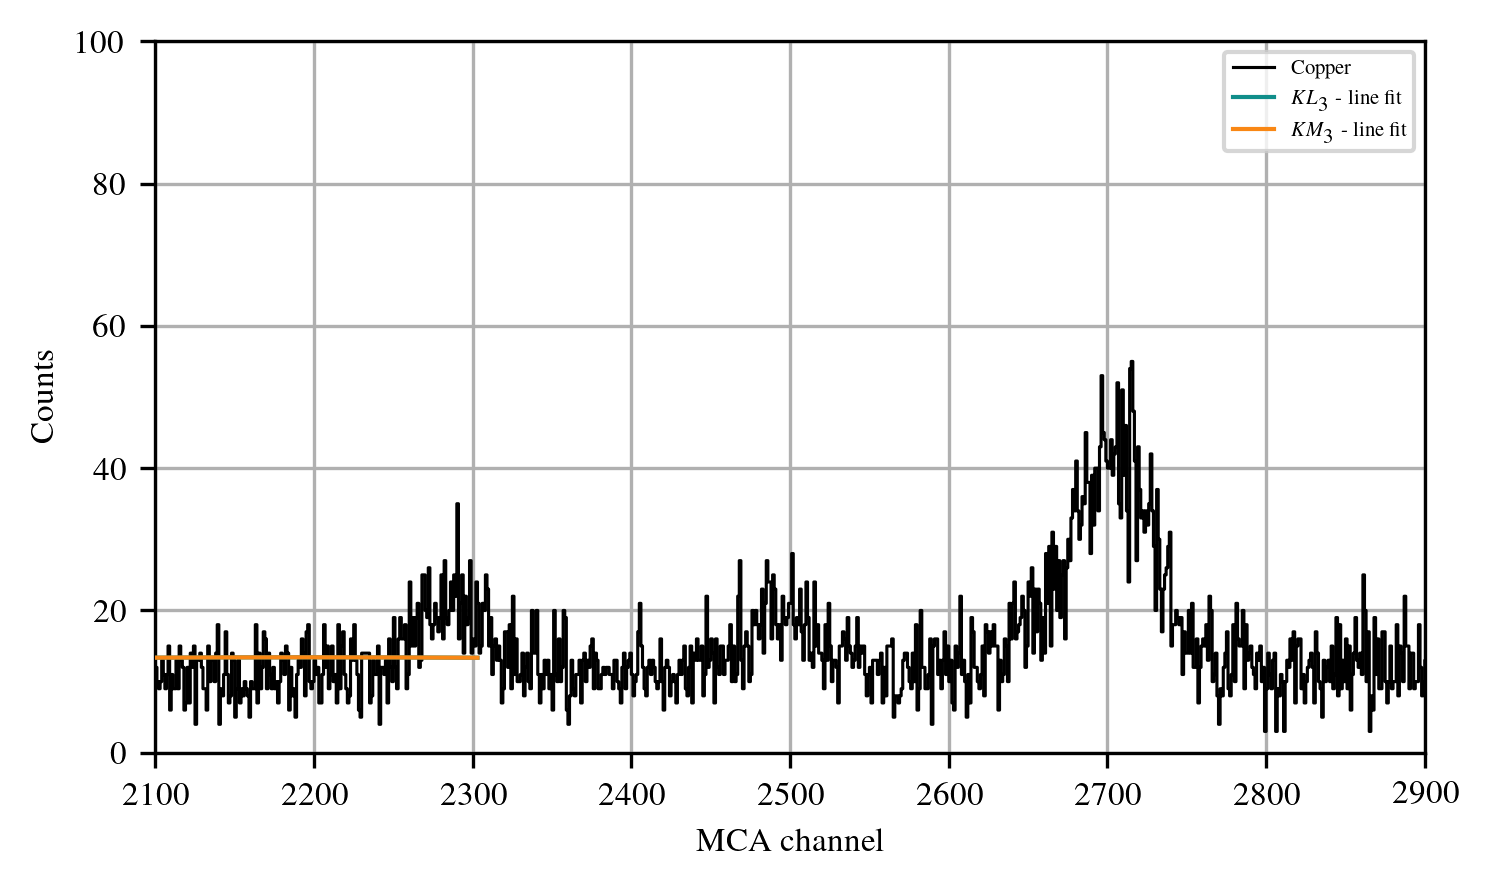

In [14]:
#------------ Copper, 3600s------------#
file_to_analyze_Cu = './/2026_03_25//20260325-070325.vspc'

init_val1 = [[905,3398,26], [200,3750,12]]
init_val2 = [[20,2275,20], [50,2700,12]]
xlim1 = [3100,3900]
xlim2 = [2100,2900]
ylim1 = []
ylim2 = [0,100]
info1 = ['Copper', '$KL_3$', '$KM_3$']
info2 = ['Copper', '$KL_3$', '$KM_3$']
gauss1 = ['single', 'single']
gauss2 = ['single', 'single']

all_peaks_one_measurement(file = file_to_analyze_Cu, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
all_peaks_one_measurement(file = file_to_analyze_Cu, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
#------------ Copper, 3600s ------------#

## Rubidium

PARAMS: [3208.36866798 5647.76242483   36.27282524]
UNCERT: [72.14756635  1.0467852   0.5840719 ]
PARAMS: [ 538.40251048 6316.50601074   37.56725767   47.54372395 6420.07215421
   30.71588336]
UNCERT: [38.85403371  3.80483297  2.75034938 18.14928055 22.51190622 12.01837234]


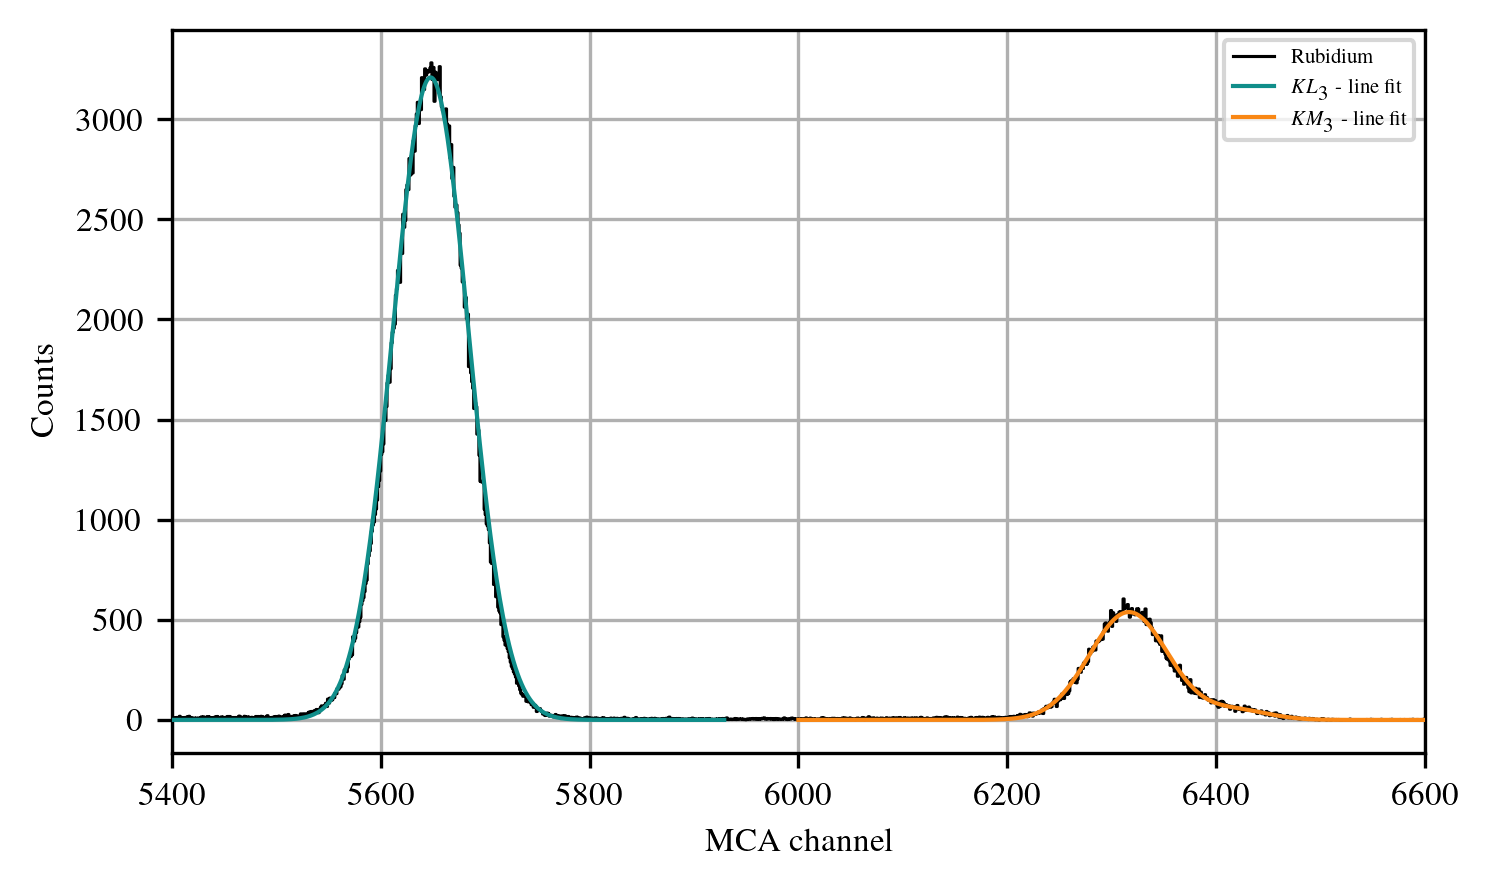

PARAMS: [ 1.53930553e+02  3.39804066e+03  2.76397130e+01 -7.68609339e-04
  6.89637348e+00]
UNCERT: [1.40350589e+01 2.32247592e+00 1.75792309e+00 5.50074918e-05
 3.30623686e-01]
PARAMS: [  14.12226394 2208.00457242 1225.83182149]
UNCERT: [ 0.59729963 47.06956517 40.40641521]


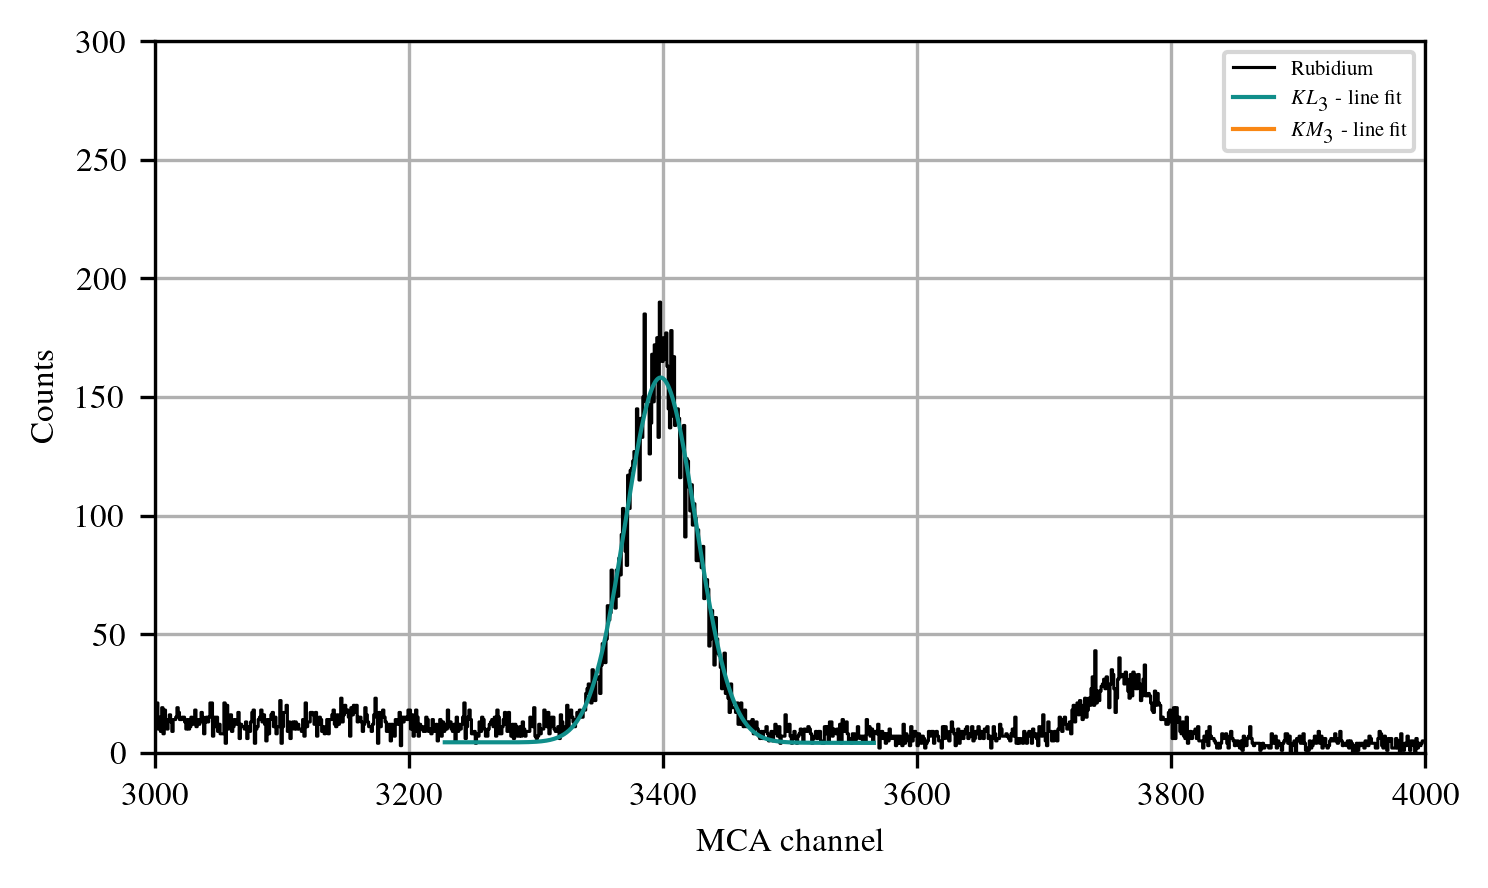

In [22]:
#------------ Rubidium, 3600s------------#
file_to_analyze_Rb = './/2026_03_25//20260325-081734.vspc'

init_val1 = [[3500,5670,26], [500,6300,25,200,6400,25]]
init_val2 = [[200,3400,20,0,50], [50,3750,12]]
xlim1 = [5400,6600]
xlim2 = [3000,4000]
ylim1 = []
ylim2 = [0,300]
info1 = ['Rubidium', '$KL_3$', '$KM_3$']
info2 = ['Rubidium', '$KL_3$', '$KM_3$']
gauss1 = ['single', 'double']
gauss2 = ['single_lin', 'single']

all_peaks_one_measurement(file = file_to_analyze_Rb, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
all_peaks_one_measurement(file = file_to_analyze_Rb, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
#------------ Rubidium, 3600s ------------#

## Molybdenium

PARAMS: [22908.71918908  3681.67629117    24.22641686]
UNCERT: [697.81208891   1.96353879   0.83804751]
PARAMS: [4082.15202288 4135.52653649   22.26810495  606.77730658 4214.0372889
   19.41157089]
UNCERT: [542.6331811    5.65620053   3.17395088 170.74429284   9.35742446
   6.14974631]


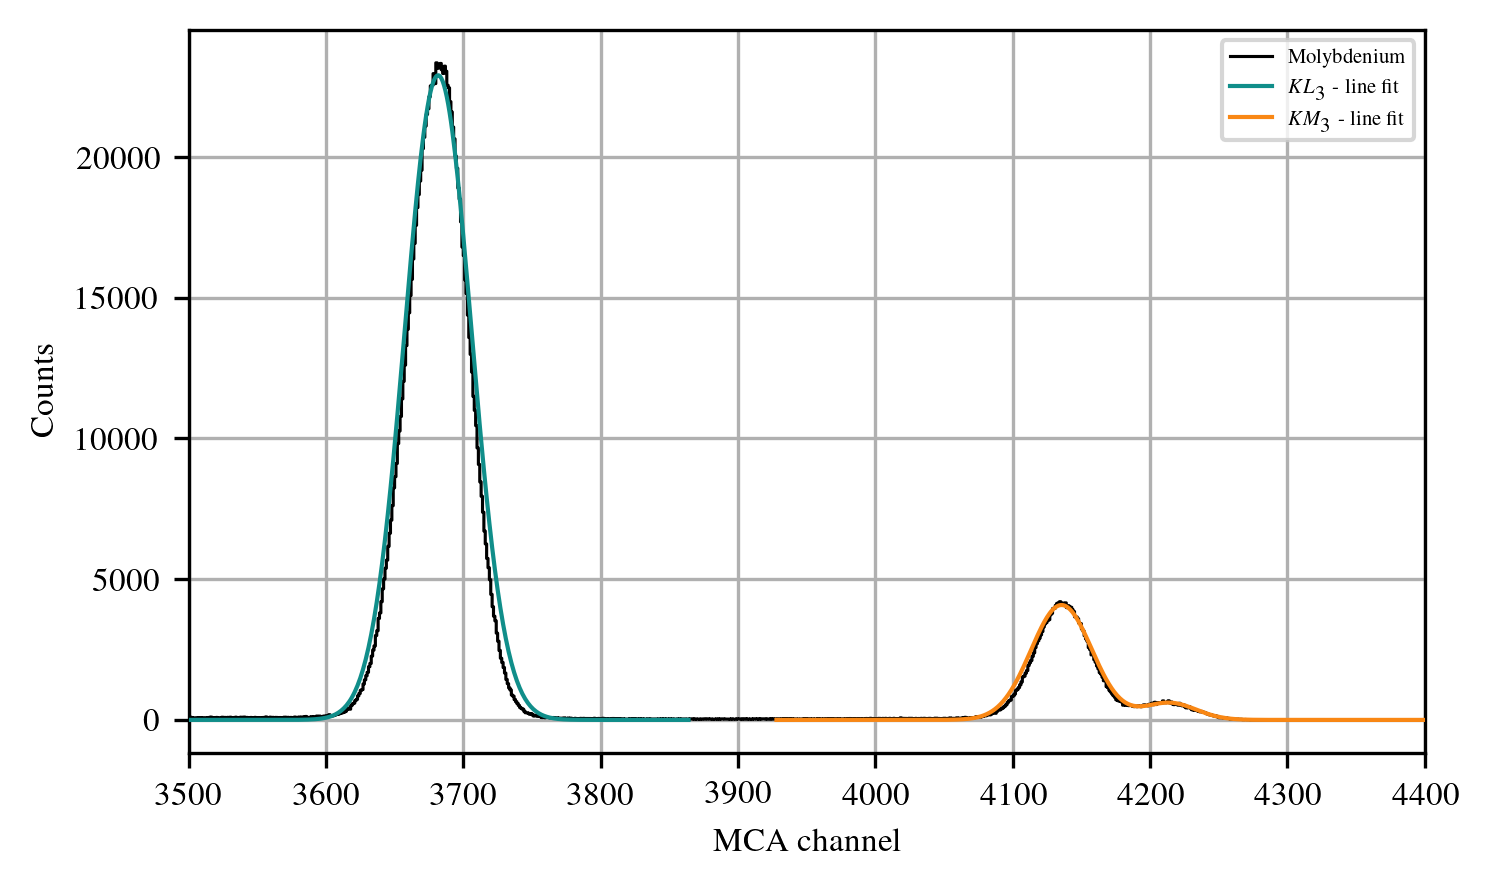

In [ ]:
#------------ Molybdenium, 3600s------------#
file_to_analyze_Mo = './/2026_03_25//20260325-092112.vspc'

init_val1 = [[23000,3700,20], [4000,4150,25,700,4220,25]]
init_val2 = [[200,3400,20,0,50], [50,3750,12]]
xlim1 = [3500,4400]
xlim2 = [3000,4000]
ylim1 = []
ylim2 = [0,300]
info1 = ['Molybdenium', '$KL_3$', '$KM_3$']
info2 = ['Molybdenium', '$KL_3$', '$KM_3$']
gauss1 = ['single', 'double']
gauss2 = ['single_lin', 'single']

all_peaks_one_measurement(file = file_to_analyze_Mo, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
# all_peaks_one_measurement(file = file_to_analyze_Mo, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
#------------ Molybdenium, 3600s ------------#

## Silver

PARAMS: [16099.53320575  4663.88285067    29.5793125 ]
UNCERT: [553.9869122    1.73630777   0.81267123]


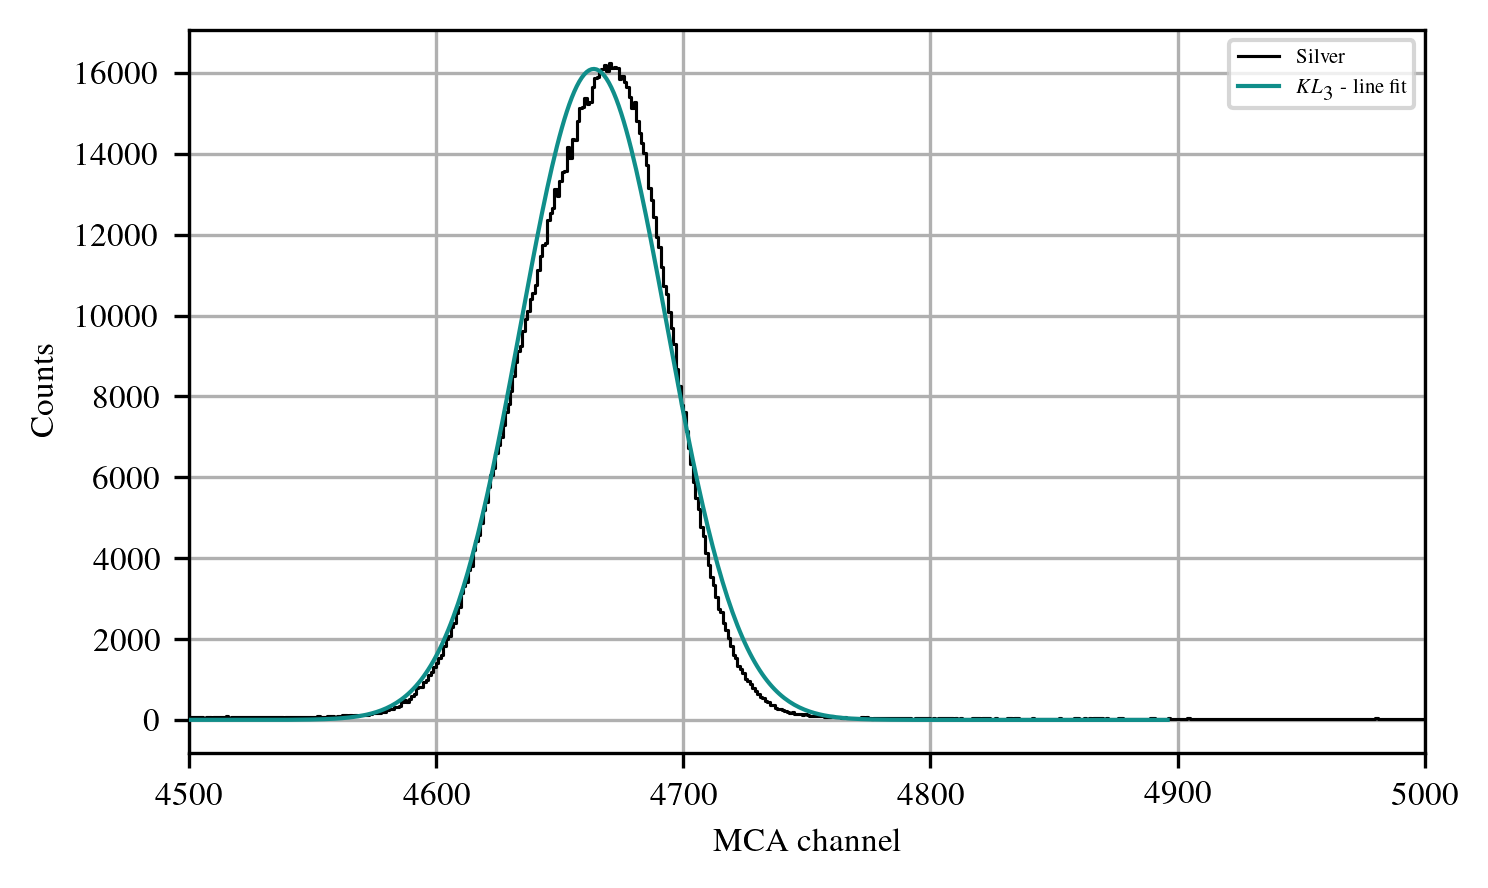

PARAMS: [3122.99083452 5260.14728843   24.45131815  530.3204605  5370.21035241
   23.11829681]
UNCERT: [385.20719426   4.65242137   2.62289238 125.27526624   6.51754892
   4.52020151]


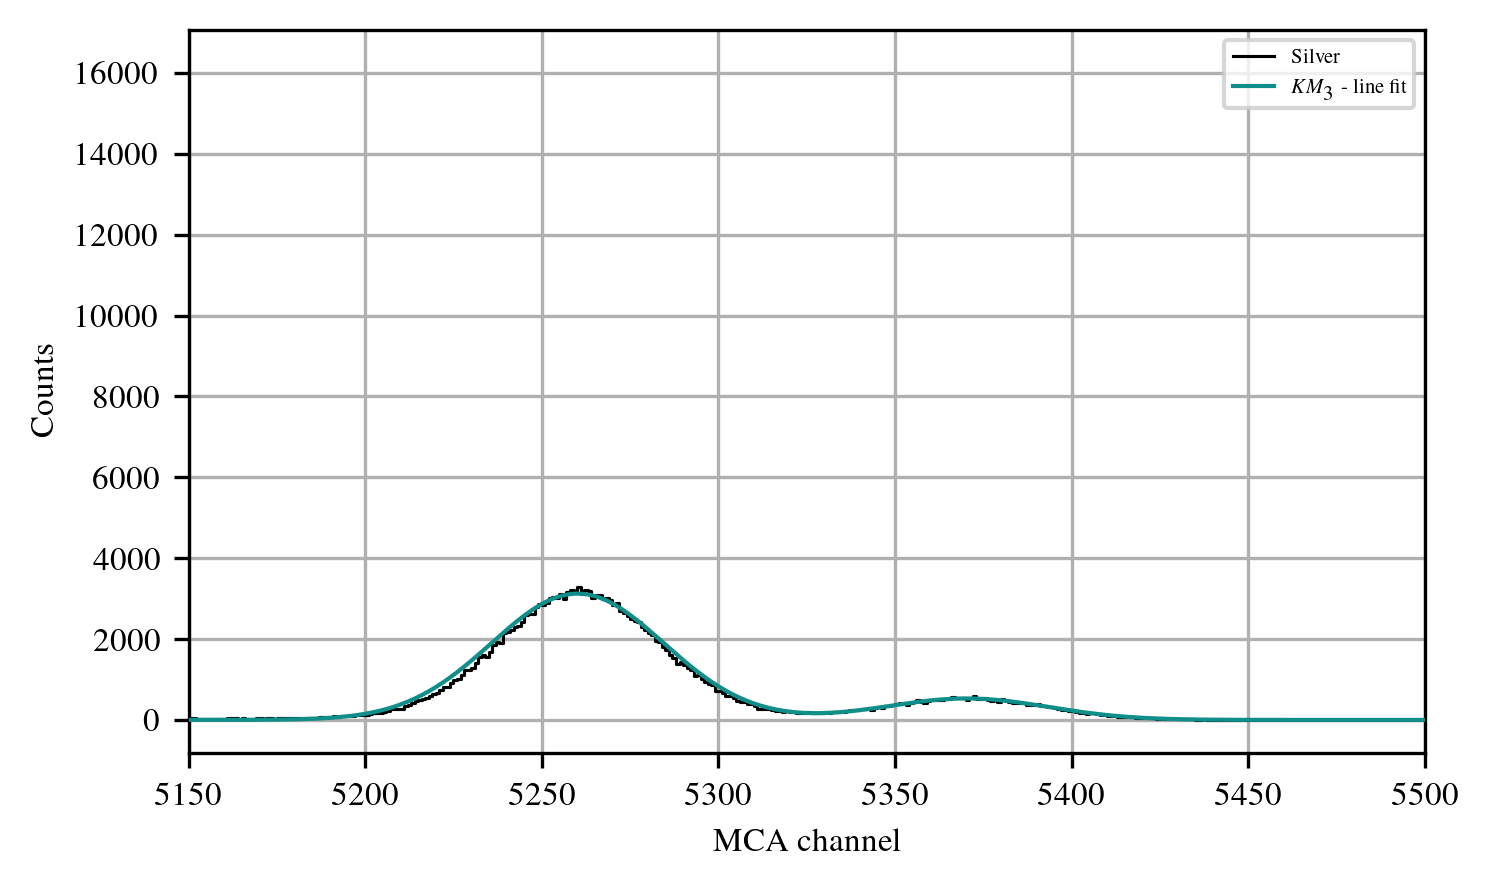

PARAMS: [254.4599616  631.99879154   6.09369907 102.08763047 661.30756154
  43.22076543]
UNCERT: [283.22541767  10.20149027   8.16335285  42.20653869  12.27901171
  10.41605891]
PARAMS: [118.6647873  321.21342289 105.05401442]
UNCERT: [15.15385525 12.07928968  8.07768808]


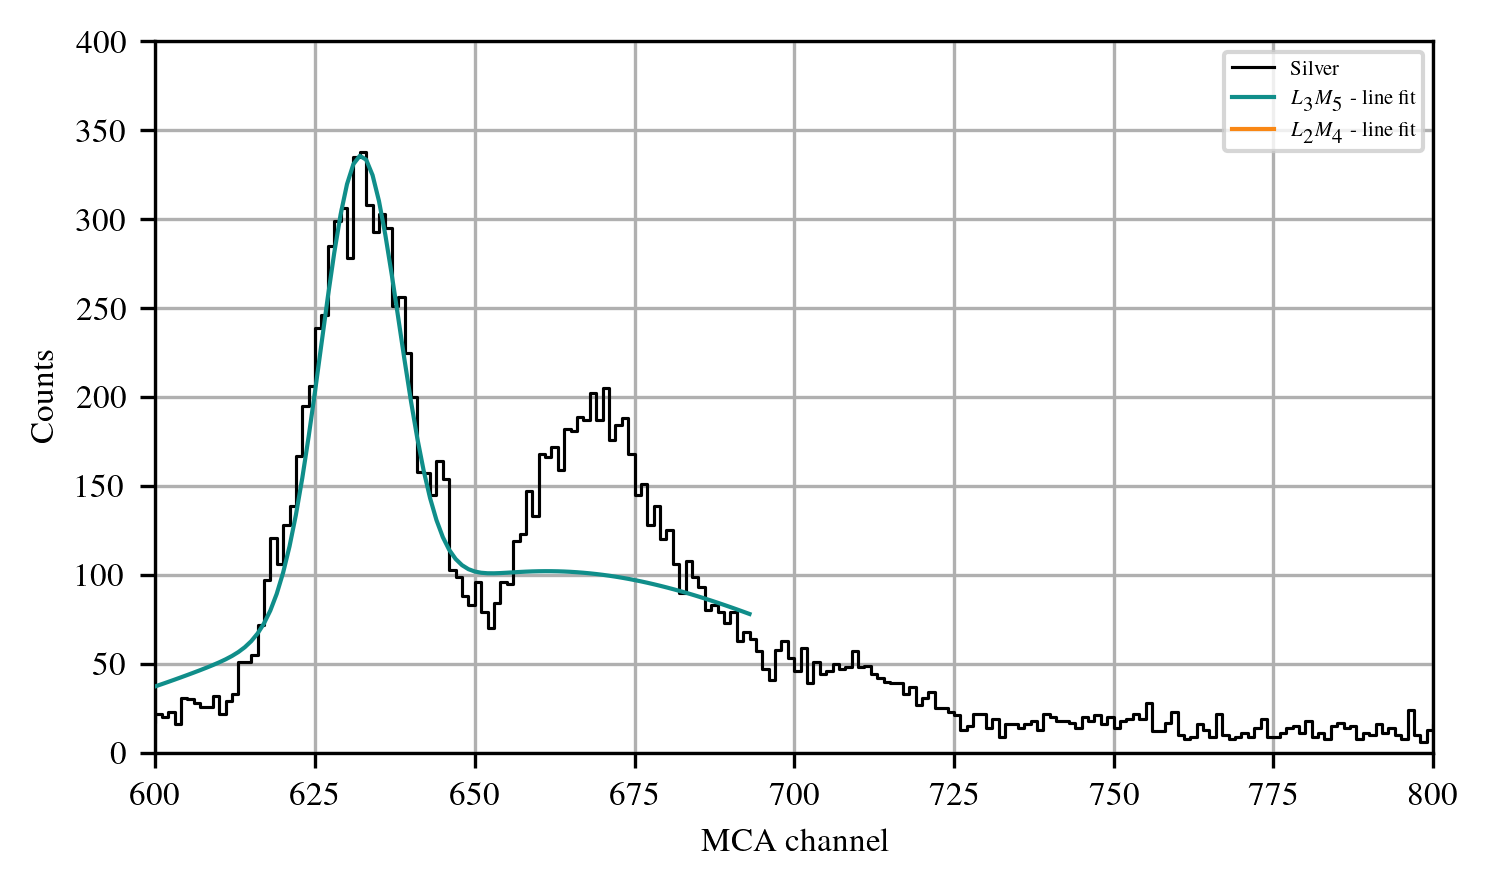

In [38]:
#------------ Silver, 3600s------------#
file_to_analyze_Ag = './/collected_data//2026_03_25//20260325-102428.vspc'

init_val1 = [[16000,4680,27]]
init_val2 = [[2950,5250,40,600,5370,20]]
init_val3 = [[350,631,8,200,661,8],[50,710,15]]
xlim1 = [4500,5000]
xlim2 = [5150,5500]
xlim3 = [600,800]
ylim1 = []
ylim2 = []
ylim3 = [0,400]
info1 = ['Silver', '$KL_3$']
info2 = ['Silver', '$KM_3$', '$KN_{2,3}$']
info3 = ['Silver', '$L_3M_5$', '$L_2M_4$']
gauss1 = ['single']
gauss2 = ['double']
gauss3 = ['double','single']

all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='0', gauss_ident=gauss3)
#------------ Silver, 3600s ------------#

## Barium

PARAMS: [1604.52498926 5095.42576137   20.30908576  885.89210938 5033.28807279
   21.06679734]
UNCERT: [166.56082197   4.44162441   2.67882375 110.76320195   5.85041581
   3.57427845]


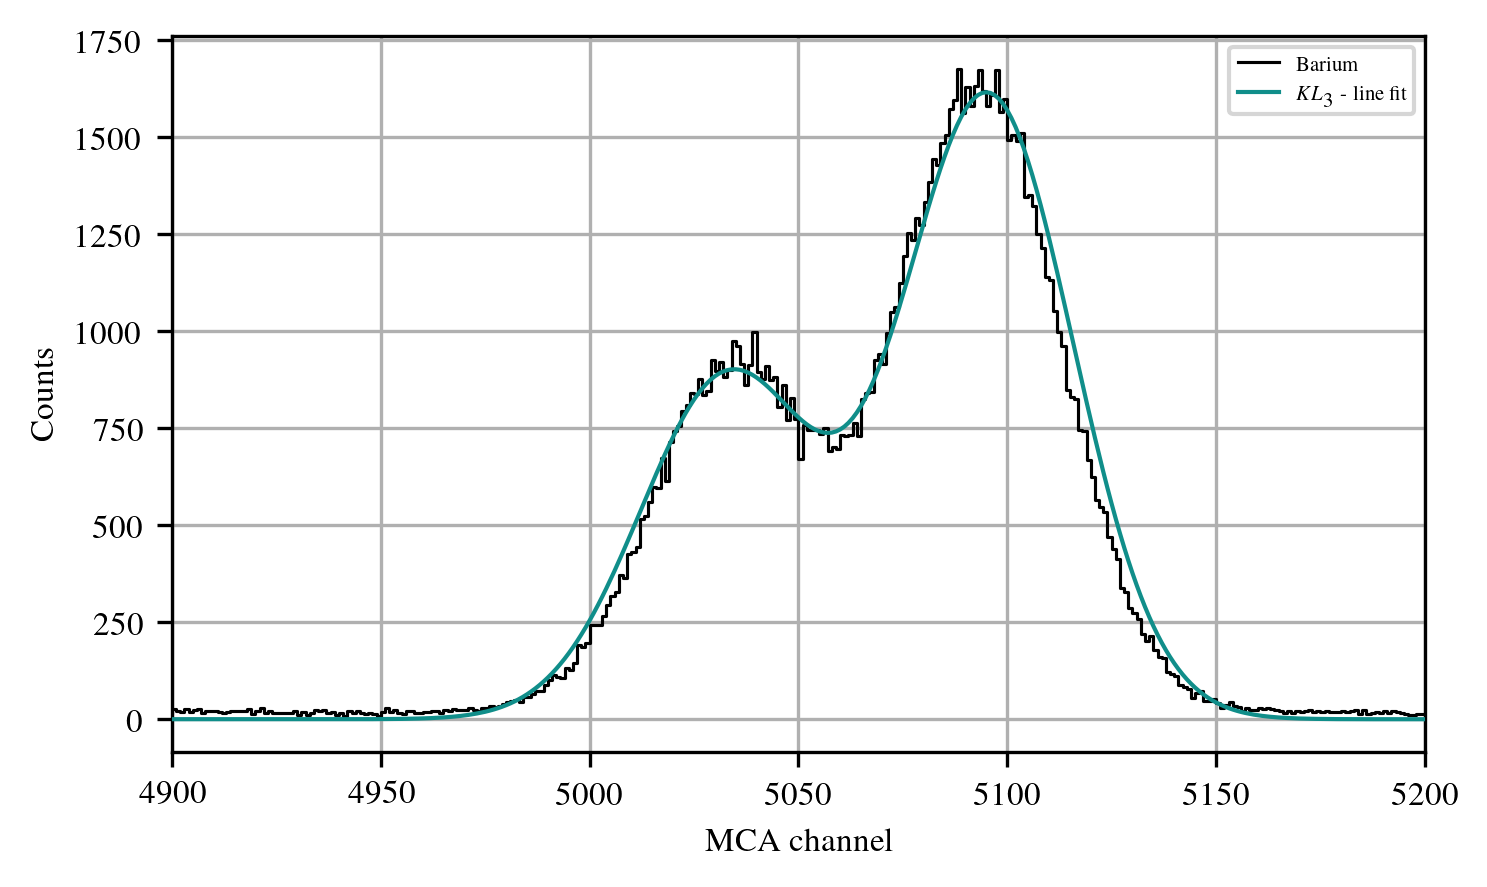

PARAMS: [3.15246890e+02 5.75219267e+03 1.98234759e+01 4.29468996e+03
 1.16933122e+05 3.29936353e+04]
UNCERT: [2.73379946e+01 1.91048306e+00 1.36595679e+00 2.85440498e+05
 1.28340003e+06 1.87736085e+05]


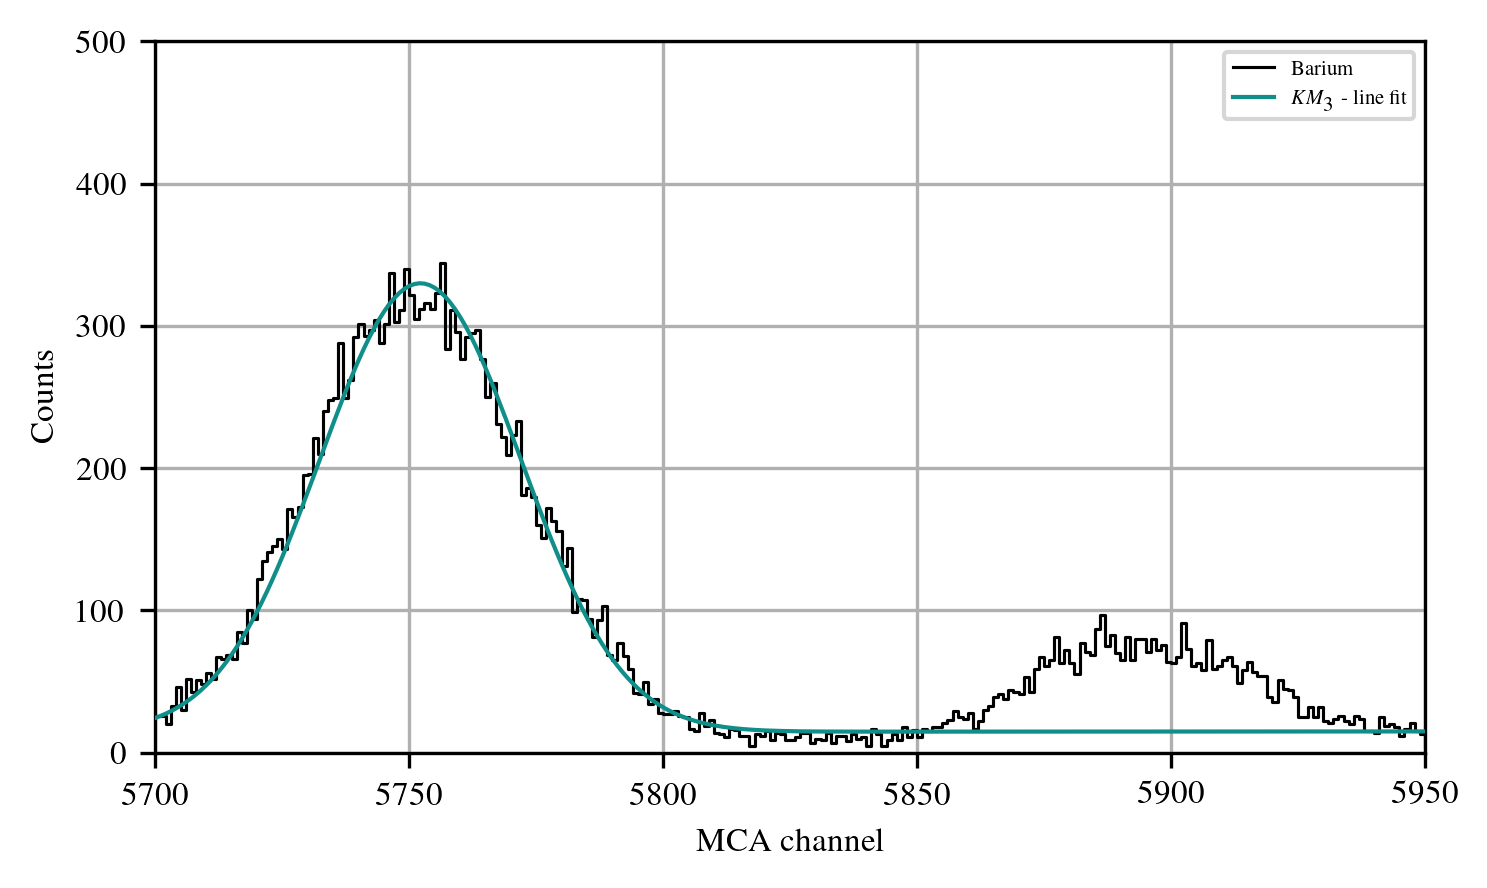

PARAMS: [991.81526987 709.32200484   7.06645151 119.46092809 834.72374118
 356.86145   ]
UNCERT: [214.73053881   2.22130512   1.44217114   3.24000451   8.15270143
   5.8833075 ]
PARAMS: [ 690.37365905 1273.54975784   15.38020628]
UNCERT: [169.90902202   4.7480391    2.60951785]


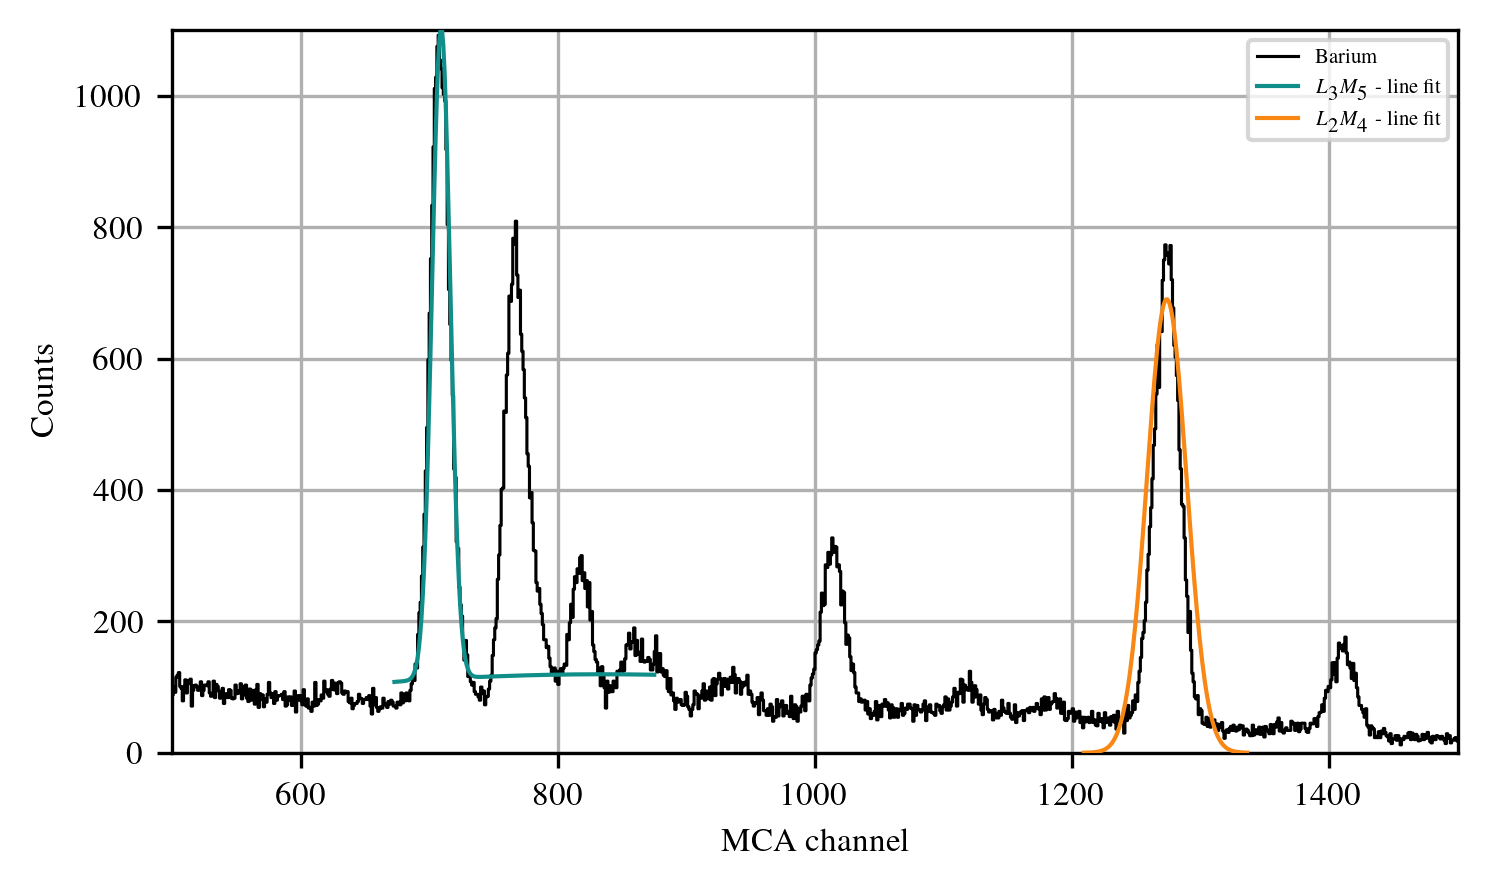

In [47]:
#------------ Barium, 3600s------------#
file_to_analyze_Ag = './/collected_data//2026_03_25//20260325-121419.vspc'

init_val1 = [[1500,5090,20,900,5000,20]]
init_val2 = [[400,5750,20,1,5880,20]]
init_val3 = [[1000,710,10,700,750,10],[750,1250,10]]
xlim1 = [4900,5200]
xlim2 = [5700,5950]
xlim3 = [500,1500]
ylim1 = []
ylim2 = [0,500]
ylim3 = [0,1100]
info1 = ['Barium', '$KL_3$','$KM_3$']
info2 = ['Barium', '$KM_3$', '$KN_{2,3}$']
info3 = ['Barium', '$L_3M_5$', '$L_2M_4$']
gauss1 = ['double']
gauss2 = ['double']
gauss3 = ['double','single']

all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
all_peaks_one_measurement(file = file_to_analyze_Ag, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='0', gauss_ident=gauss3)
#------------ Barium, 3600s ------------#

## Terbium

PARAMS: [1270.152076   6368.91296193   23.18461956 2188.13070171 6478.49128777
   22.50735474]
UNCERT: [132.73898971   3.25876809   2.04714923 196.45561207   3.02523783
   1.75699417]


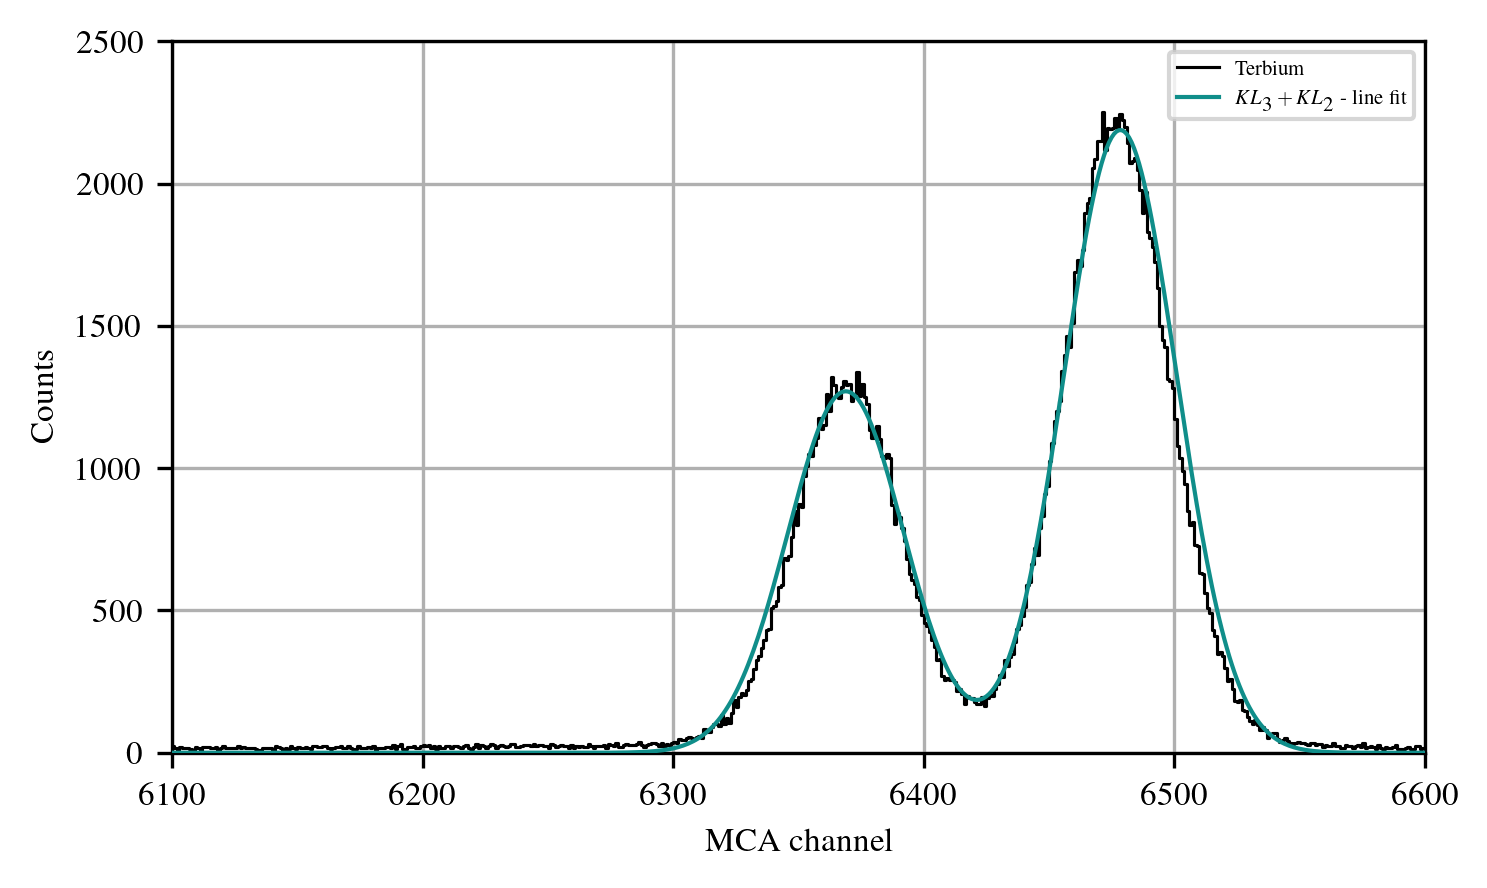

PARAMS: [4101.6547868   914.32350312   16.34705079]
UNCERT: [549.02268824   3.83068902   1.69727042]
PARAMS: [3359.26507004 1015.34299568   14.64314763 1004.13004955 1077.61692611
   13.46853909]
UNCERT: [583.71599713   4.86138373   2.39280477 255.12017897   5.56919817
   3.32696906]


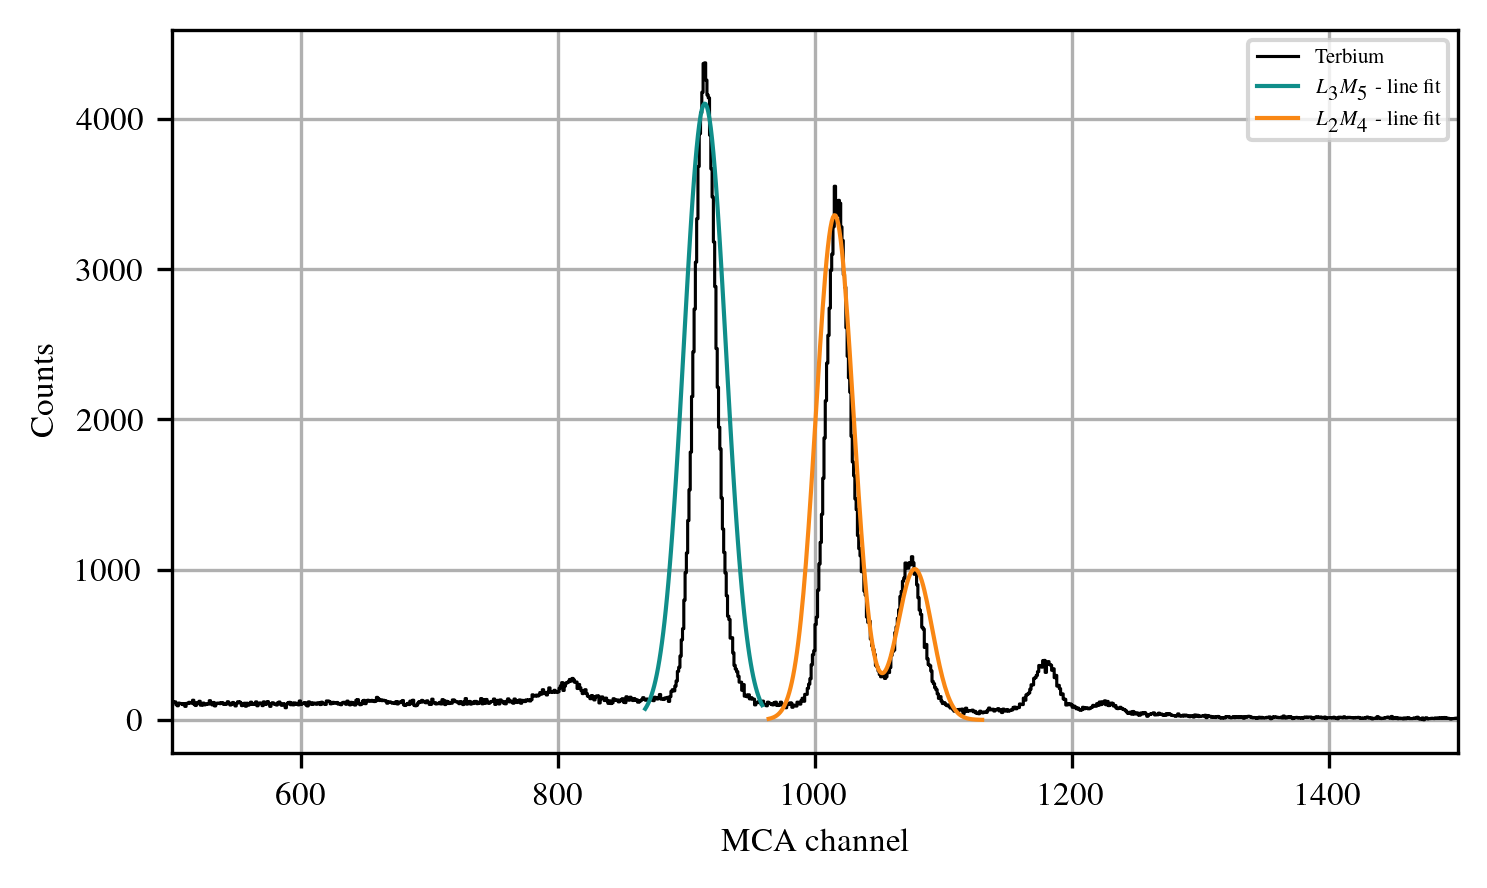

In [26]:
#------------ Terbium, 3600s------------#
file_to_analyze_Tb = './/collected_data//2026_03_25//20260325-132058.vspc'

init_val1 = [[1200,6350,20,2100,6470,20]]
init_val2 = [[500,7325,20],[100,7550,20]]
init_val3 = [[4000,900,17],[3500,1020,21,1000,1070,20]]
xlim1 = [6100,6600]
xlim2 = [7200,7700]
xlim3 = [500,1500]
ylim1 = [0,2500]
ylim2 = [0,500]
ylim3 = []
info1 = ['Terbium', '$KL_3 + KL_2$']
info2 = ['Terbium', '$KM_3$', '$KN_{2,3}$']
info3 = ['Terbium', '$L_3M_5$', '$L_2M_4$']
gauss1 = ['double']
gauss2 = ['single','single']
gauss3 = ['single','double']

all_peaks_one_measurement(file = file_to_analyze_Tb, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
# all_peaks_one_measurement(file = file_to_analyze_Tb, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='0', gauss_ident=gauss2)
all_peaks_one_measurement(file = file_to_analyze_Tb, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='0', gauss_ident=gauss3)
#------------ Terbium, 3600s ------------#